features: ux, uy, cp, nu_tilde, eddie_viscosity, implicit_distance
target: ux, uy, cp

In [1]:
import gc
import numpy as np
import matplotlib.pyplot as plt
import torch
from itertools import product
from warnings import filterwarnings

from src.utils.commons import get_config, get_device, set_seed
from src.model.gae import GAE
from torch_geometric.loader import DataLoader
from src.training.train_surface import train
from src.data.loader import GraphDataset
from src.utils.commons import get_config

filterwarnings('ignore')
torch.cuda.empty_cache()
gc.collect()

config = get_config('configs/VEL_P_NACA0012Cheb.yaml')
set_seed(config['config']['seed'])

train_dataset = GraphDataset(config = config['config'], split = 'train')
val_dataset = GraphDataset(config = config['config'], split = 'val')
device = get_device()

train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=1, 
                          shuffle=False,
                          num_workers=config['training']['num_workers'])

val_loader = DataLoader(dataset=val_dataset, 
                        batch_size=1, 
                        shuffle=False,
                        num_workers=config['training']['num_workers'])
    
surface_mask = train_dataset.surface_mask

linear_ae_input_size = train_dataset[0].x.shape[0] * config["model"]['encoder']['convolution_layers']['hidden_channels'][-1]
model = GAE(config = config, ae_input_size = linear_ae_input_size).to(device)

In [2]:
linear_ae_input_size

116608

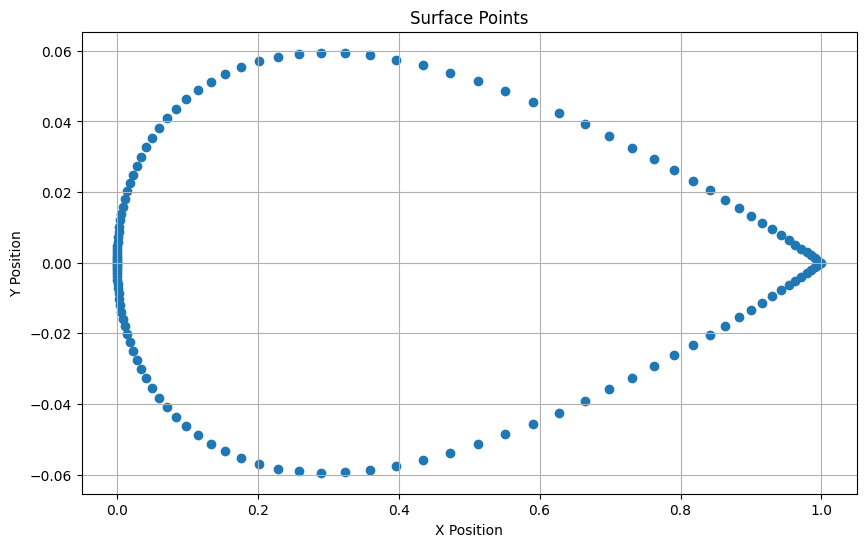

In [3]:
import matplotlib.pyplot as plt
surface_point = train_dataset[0].pos[surface_mask, :]
plt.figure(figsize=(10, 6))
plt.scatter(surface_point[:, 0].cpu().numpy(), surface_point[:, 1].cpu().numpy())
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Surface Points')
plt.grid(True)
plt.show()

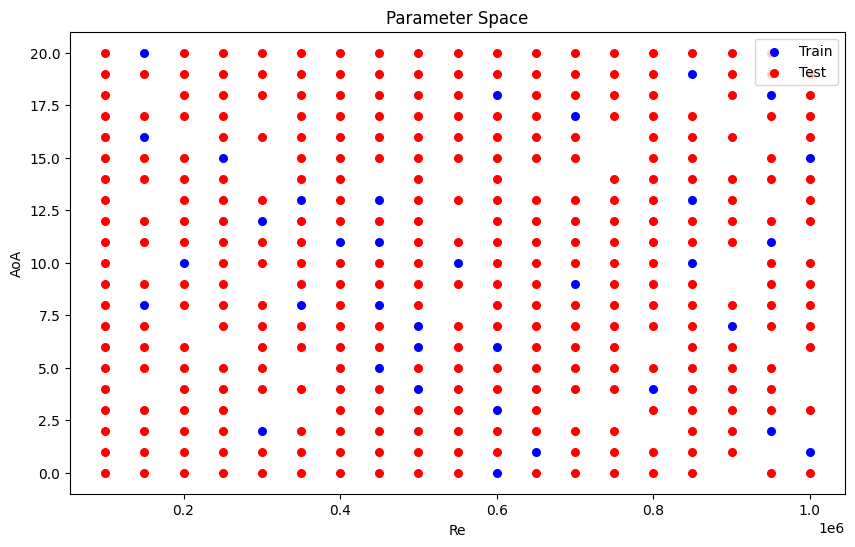

In [4]:
train_params_list = np.array([[int(keys.split('_')[1]), int(keys.split('_')[3])] for keys in train_dataset.file_keys]).reshape(-1, 2)
test_params_list = np.array([[int(keys.split('_')[1]), int(keys.split('_')[3])] for keys in val_dataset.file_keys]).reshape(-1, 2)

plt.figure(figsize=(10, 6))
# plt.grid(True)
plt.xlabel('Re')
plt.ylabel('AoA')
plt.title('Parameter Space')
plt.scatter(train_params_list[:, 0], train_params_list[:, 1], c='blue', s=30, label='Train')
plt.scatter(test_params_list[:, 0], test_params_list[:, 1], c='red', s=30, label='Test')
plt.legend()
plt.show()

## Training

In [5]:
config

{'config': {'seed': 10,
  'device': 'cuda',
  'root_dir': './',
  'dataset_dir': 'dataset/flows',
  'split_dir': 'dataset/final_h5_files',
  'output_dir': './output/',
  'mesh_file': 'dataset\\full\\flow_Re_400000_alpha_10.vtu',
  'data_sample': 1000,
  'variable_scaling': True,
  'scaler_name': 'standard',
  'scaling_type': 4,
  'inverse_scaling': True,
  'dim_pde': 6,
  'variable': 'full'},
 'preprocessing': {'normalization_method': 'zscore',
  'with_edge_features': True},
 'conv_base': {'type': 'Cheb',
  'act': 'ELU',
  'head': 4,
  'dropout': 0,
  'kernel_size': 5,
  'K': 7,
  'dim': 1,
  'num_layers': 5,
  'is_batch_norm': True,
  'is_skip_connection': False},
 'model': {'encoder': {'convolution_layers': {'type': 'Cheb',
    'act': 'ELU',
    'head': 4,
    'dropout': 0,
    'kernel_size': 5,
    'K': 7,
    'dim': 1,
    'num_layers': 5,
    'is_batch_norm': True,
    'is_skip_connection': False,
    'hidden_channels': [6, 32, 32, 32, 8]}},
  'decoder': {'convolution_layers': {'t

In [6]:
history = train(model = model, 
                device = device, 
                surface_mask = surface_mask,
                lambda_surface=1,
                train_loader = train_loader, 
                is_val = True,
                val_loader = val_loader, 
                start_up_epoch=20,
                save_best_model=True,
                save_history=True,
                config = config['training'])

train_history, val_history = history
from src.utils.commons import save_config
save_config(config, task='surface')

  8%|▊         | 84/1000 [24:26<4:26:35, 17.46s/it, train_loss=0.096931, map_loss=0.011640, reconstruction_loss=0.085291, val_loss=0.271848, val_reconstruction_loss=0.150313, val_map_loss=0.121535]


RuntimeError: CUDA error: an illegal memory access was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [6]:
from src.training.fine_tune_mapping import fine_tune_mapping
mapping_model = fine_tune_mapping(model,    
                                  device=device, 
                                  train_loader=train_loader, 
                                  val_loader=val_loader, 
                                  config=config['training'],
                                  epoch=200,
                                  save_best_model=True,
                                  save_history=True)

  0%|          | 0/200 [00:04<?, ?it/s]


KeyboardInterrupt: 

### Plot train total loss and val total loss

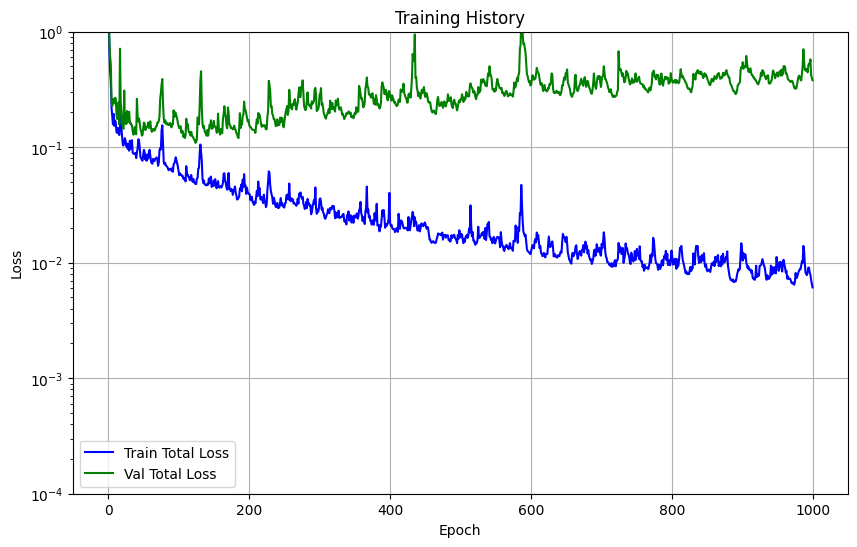

In [11]:
import pickle
import matplotlib.pyplot as plt
from src.utils.commons import get_config

config = get_config('configs/VEL_P_NACA0012Cheb.yaml')
model_name = config['training']['model_name']
num_epochs = config['training']['epochs']

with open(f"artifacts/surface/{model_name}/{model_name}_history_{num_epochs}.pkl", 'rb') as f:
    # Load the history dictionary
    train_history = pickle.load(f)
    val_history = pickle.load(f)
    
train_total_loss = train_history['train_loss']
val_total_loss = val_history['val_loss']    

plt.figure(figsize=(10, 6))
plt.plot(train_total_loss, label='Train Total Loss', color='blue')
plt.plot(val_total_loss, label='Val Total Loss', color='green')
plt.ylim(0.0001, 1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)
plt.yscale('log') 
plt.show()

### Plot train loss history

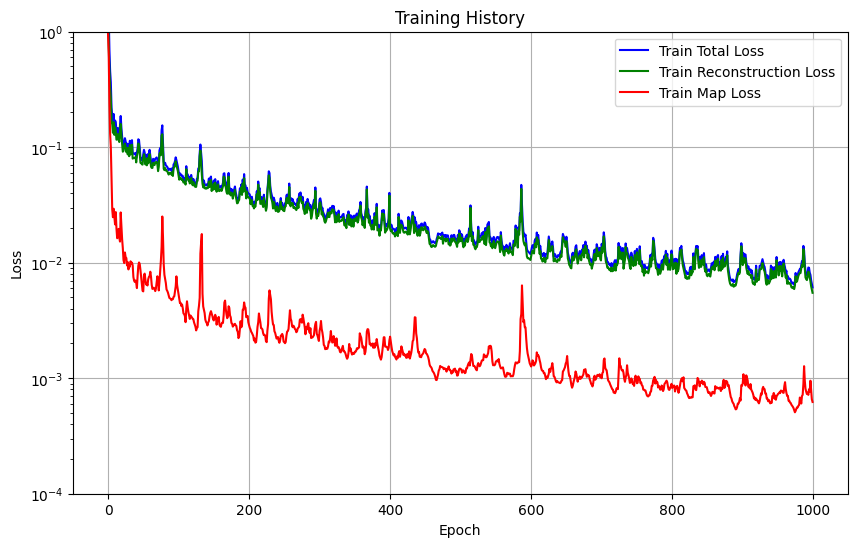

In [8]:
train_total_loss = train_history['train_loss']
train_reconstruction_loss = train_history['reconstruction_loss']
train_map_loss = train_history['map_loss']

plt.figure(figsize=(10, 6))
plt.plot(train_total_loss, label='Train Total Loss', color='blue')
plt.plot(train_reconstruction_loss, label='Train Reconstruction Loss', color='green')
plt.plot(train_map_loss, label='Train Map Loss', color='red')
plt.ylim(0.0001, 1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)
plt.yscale('log') 
plt.show()

### Plot validation loss history

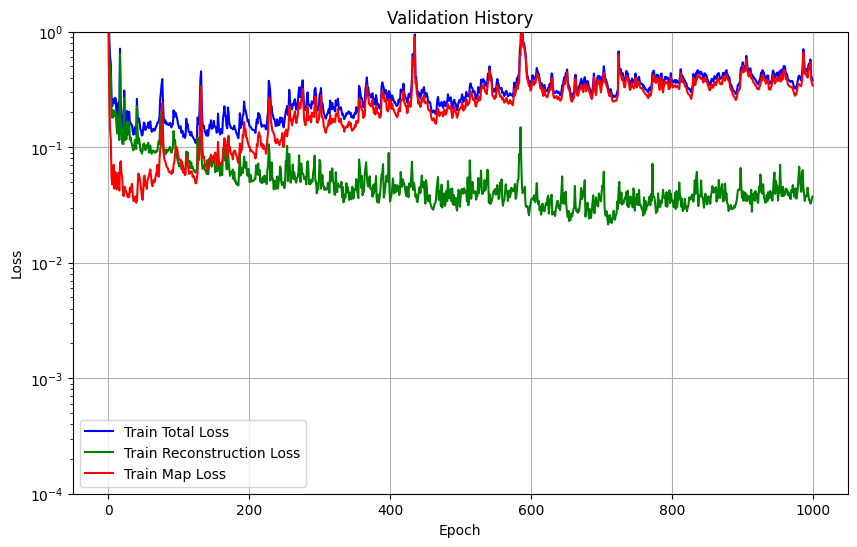

In [ ]:
val_total_loss = val_history['val_loss']
val_reconstruction_loss = val_history['reconstruction_loss']
val_map_loss = val_history['map_loss']

plt.figure(figsize=(10, 6))
plt.plot(val_total_loss, label='Train Total Loss', color='blue')
plt.plot(val_reconstruction_loss, label='Train Reconstruction Loss', color='green')
plt.plot(val_map_loss, label='Train Map Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0001, 1)
# plt.ylim(0.001, 10)
plt.title('Validation History')
plt.legend()
plt.grid(True)
plt.yscale('log') 
plt.show()

## Plot results

### Matplotlib Plotting

In [ ]:
from src.utils.plot import Plot
from src.utils.commons import load_model
import gc
import numpy as np
import torch
from itertools import product
from warnings import filterwarnings

from src.utils.commons import get_config, get_device, set_seed
from src.data.loader import GraphDataset
from src.utils.commons import get_config

filterwarnings('ignore')
torch.cuda.empty_cache()
gc.collect()

config = get_config('configs/VEL_P_NACA0012Cheb.yaml')
set_seed(config['config']['seed'])
num_epochs = config['training']['epochs']
model_name = config['training']['model_name']

train_dataset = GraphDataset(config = config['config'], split = 'train')
val_dataset = GraphDataset(config = config['config'], split = 'val')
device = get_device()

model = load_model(f"artifacts/surface/{model_name}/{model_name}_best_model_{num_epochs}.pth", config=config, ae_input_ize=train_dataset[0].x.shape[0] * config["model"]['encoder']['convolution_layers']['hidden_channels'][-1])
model = model.to(device)
plot = Plot(train_dataset=train_dataset, val_dataset=val_dataset, model=model)

index = 27

test_plot_data = val_dataset[index].to(device)
test_param = test_plot_data.params

estimated_x, latent_variables, estimated_latent_variables = model(test_plot_data, test_param)
estimated_x = estimated_x.detach().cpu().numpy()

Original

    raw_velocities = np.array(grid.point_data[vtu_array_name], dtype=np.float32)
    raw_pressure = np.array(grid.point_data['Pressure'], dtype=np.float32)
    cp = np.array(grid['Pressure_Coefficient'], dtype=np.float32)
    cf = np.array(grid['Skin_Friction_Coefficient'], dtype=np.float32)[:,:2]
    Y_plus = np.array(grid['Y_Plus'], dtype=np.float32)
    nutilde = np.array(grid['Nu_Tilde'], dtype=np.float32)
    eddy_viscosity = np.array(grid['Eddy_Viscosity'], dtype=np.float32)

Using v_range: 3.3236069679260254


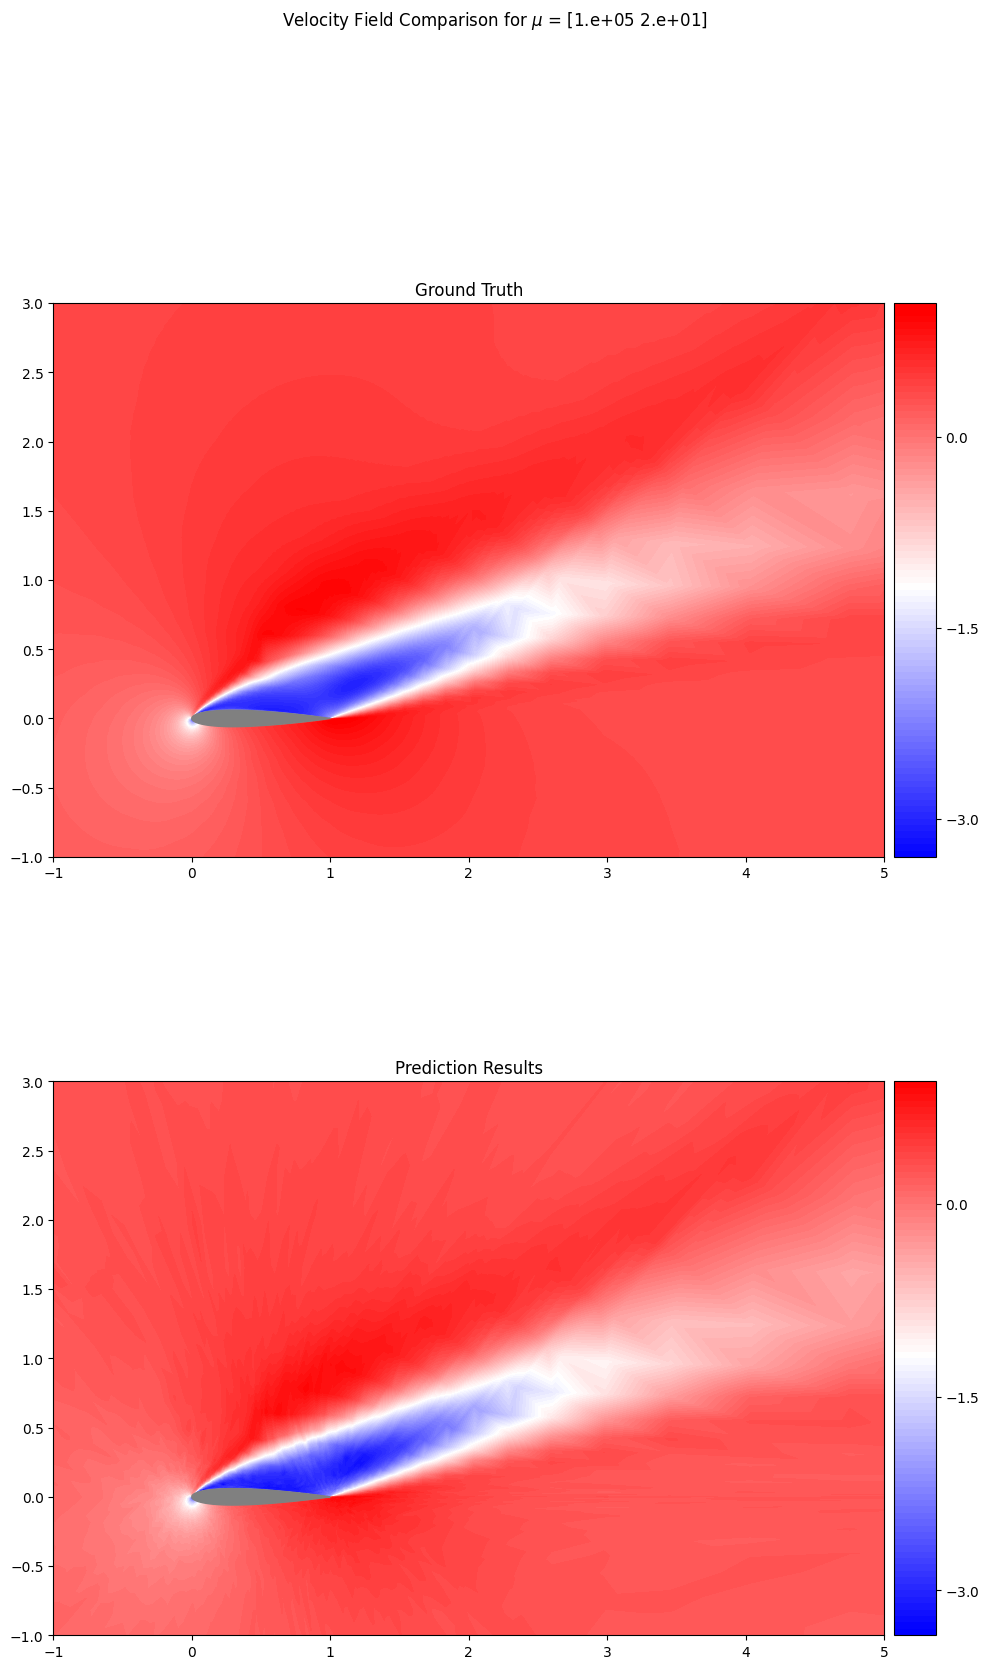

Using v_range: 3.3236069679260254


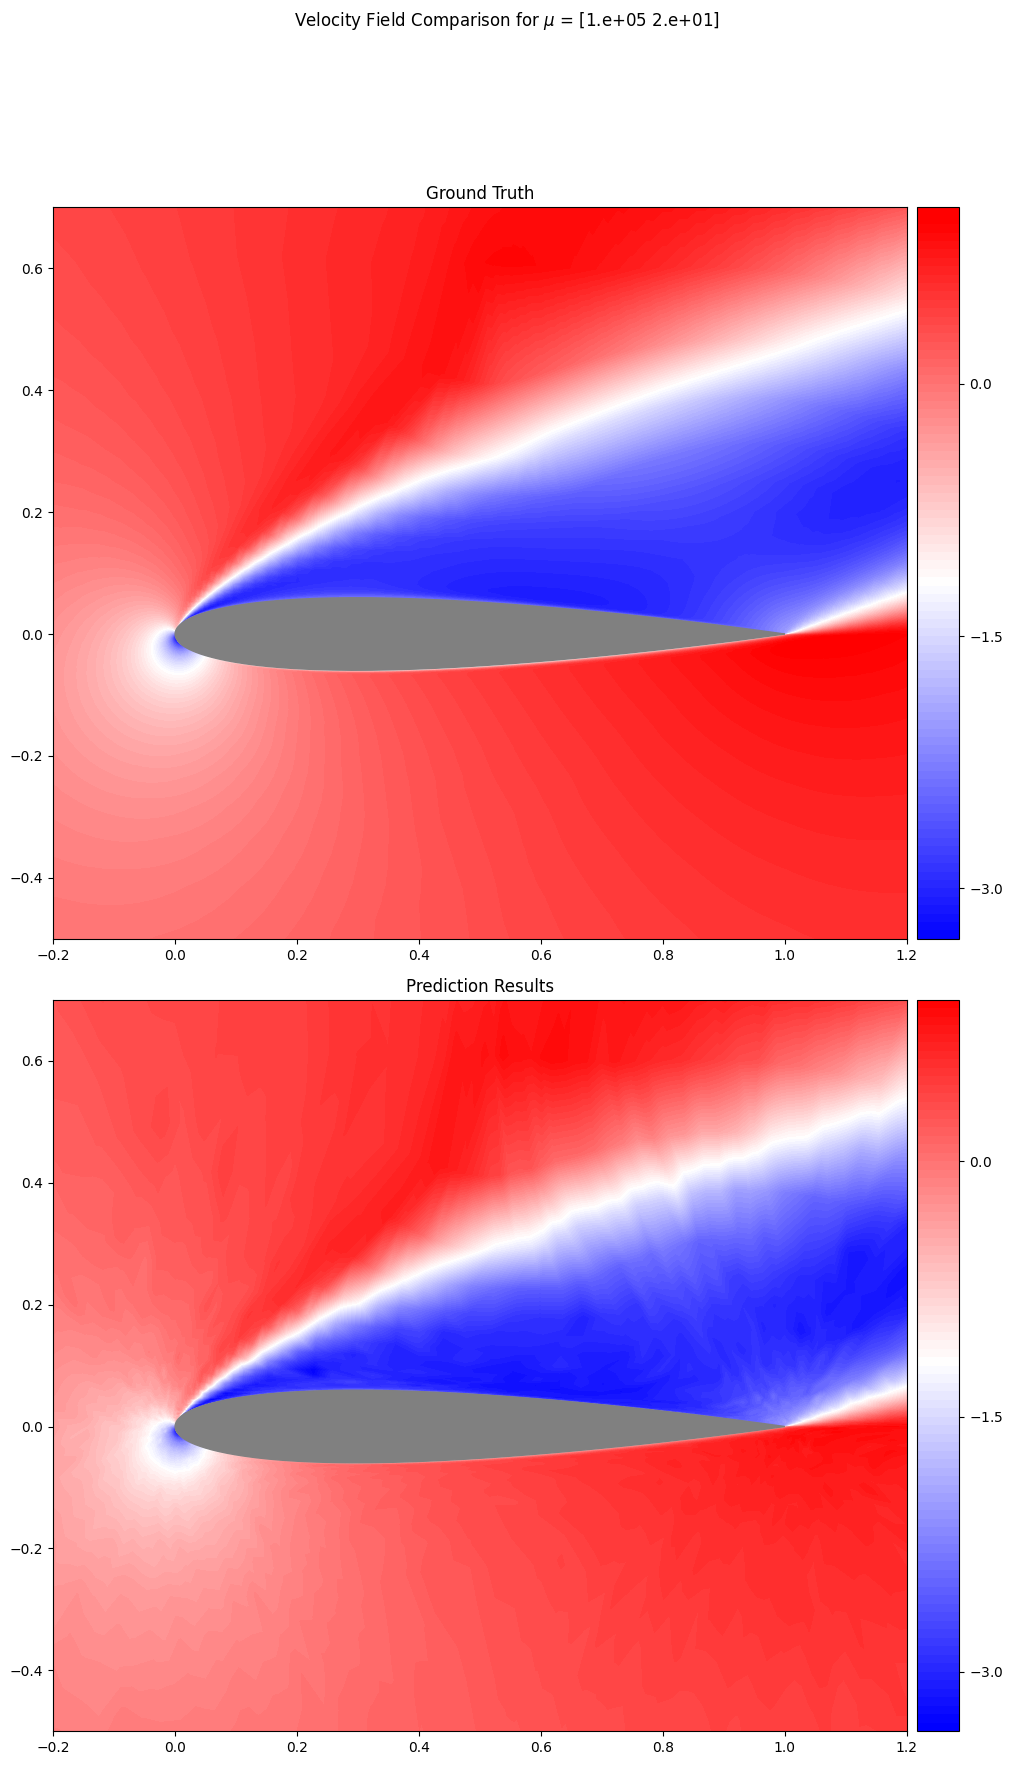

Using v_range: 4.804494380950928


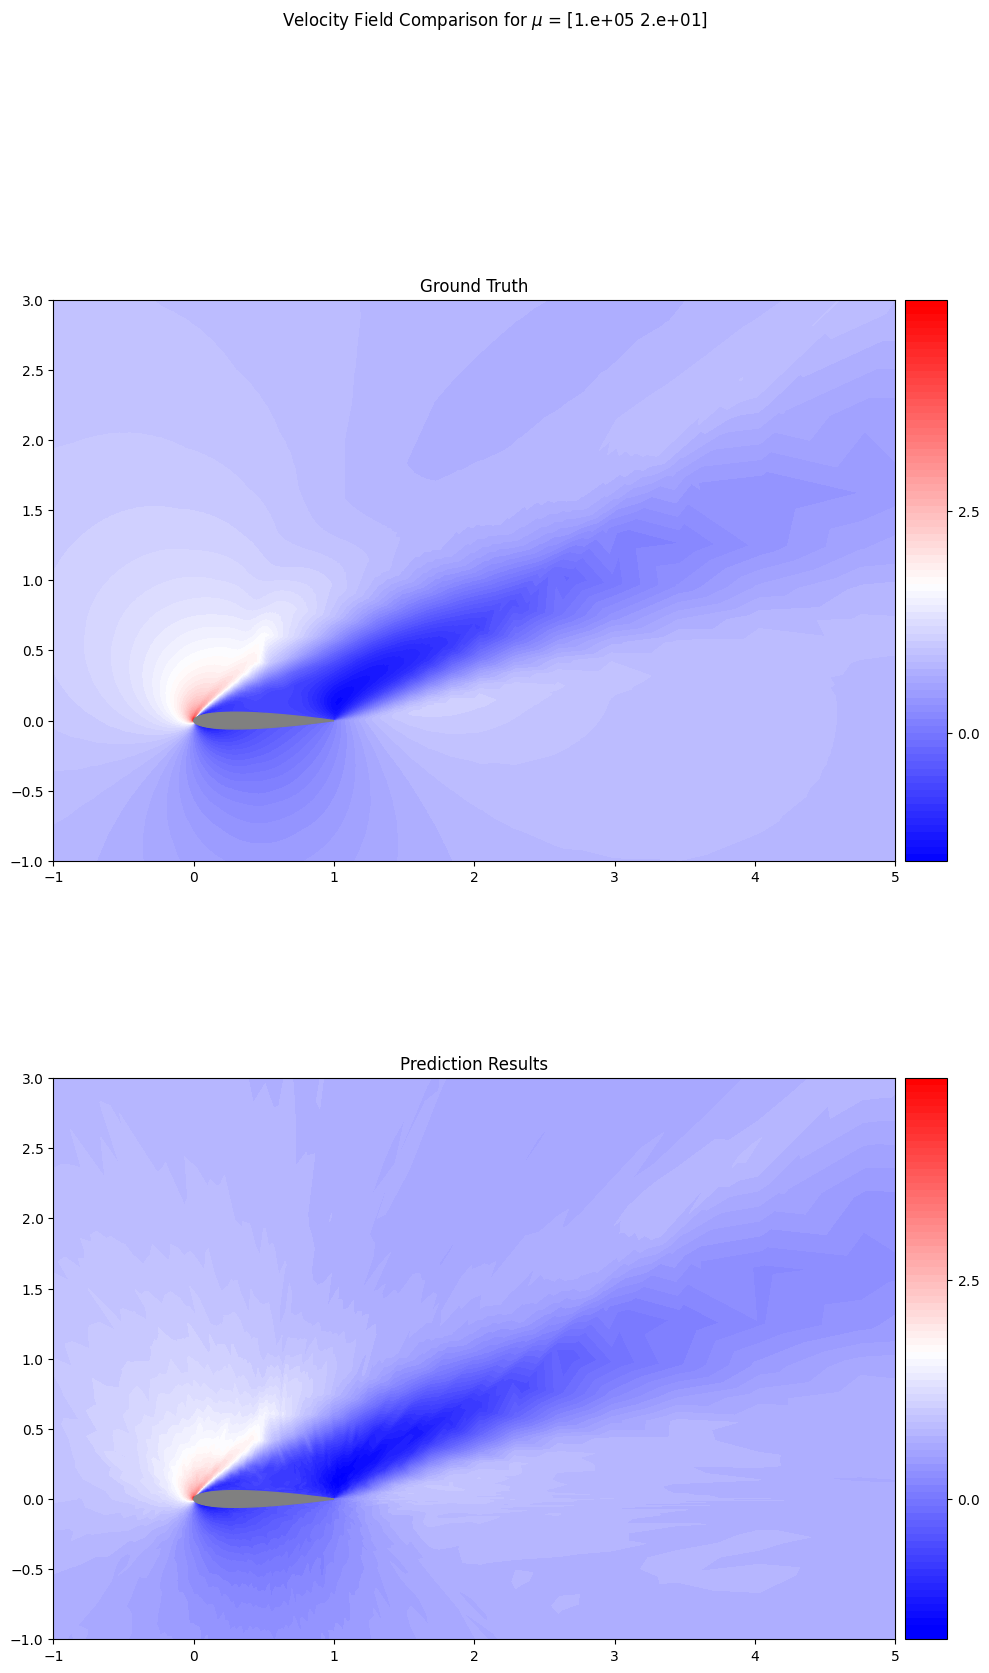

Using v_range: 4.804494380950928


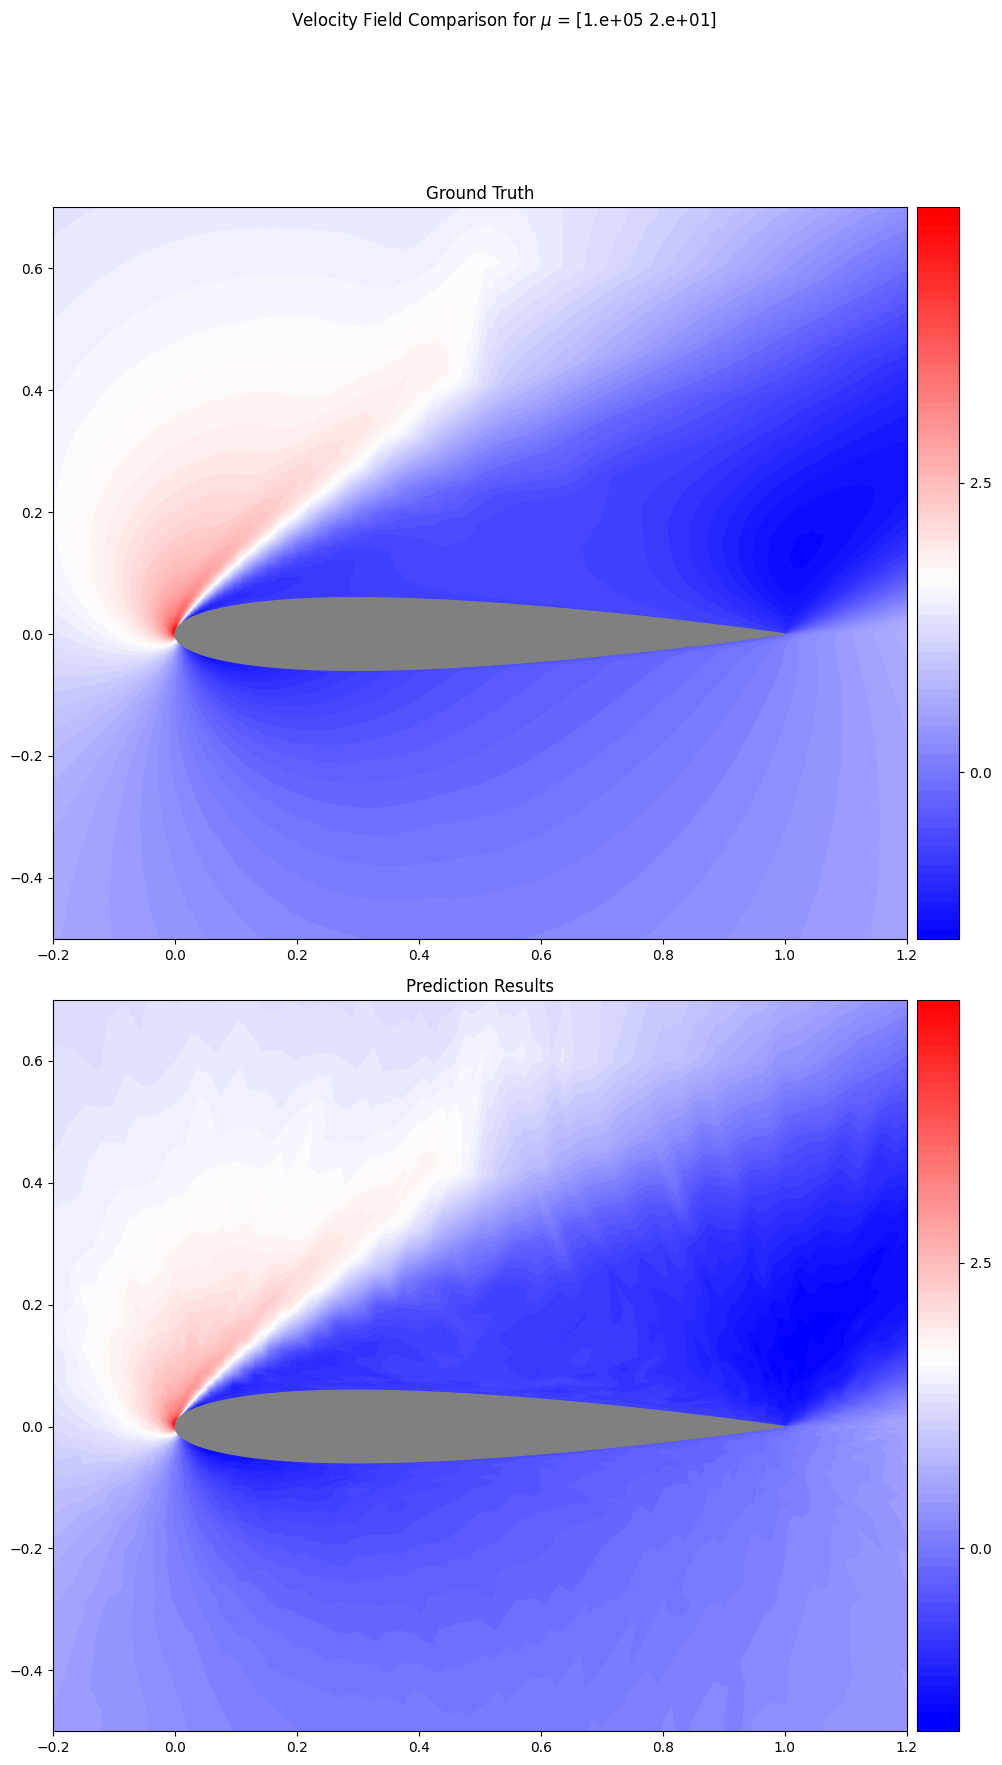

Using v_range: 1.9380453824996948


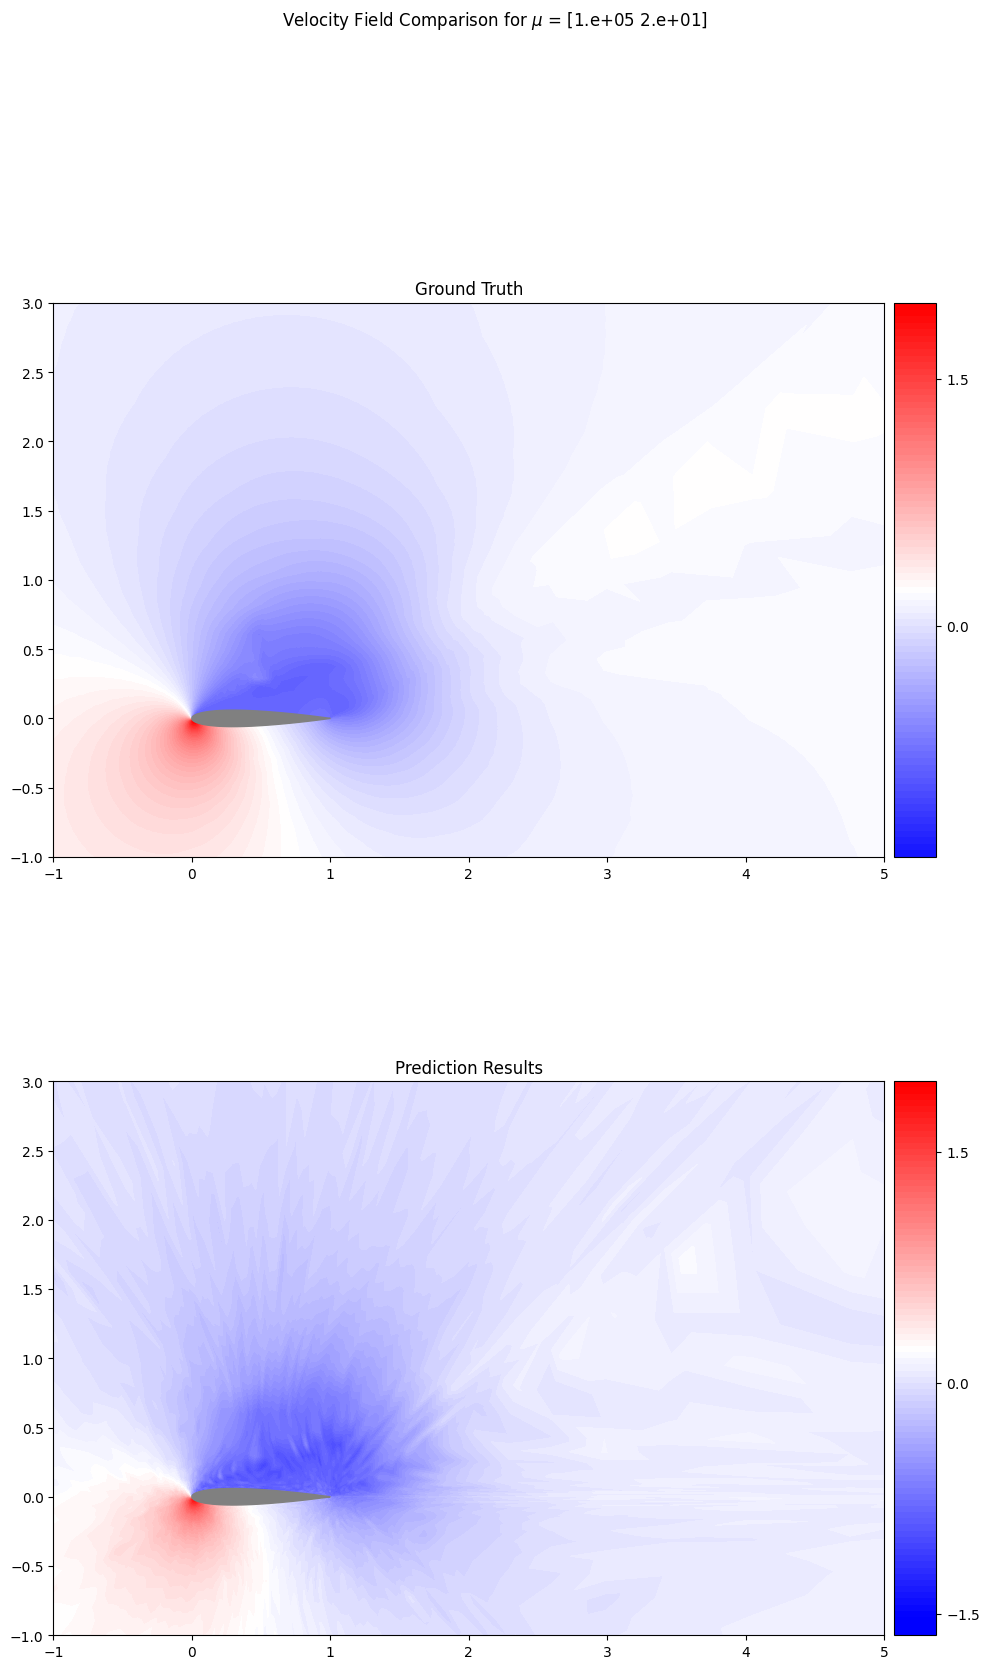

Using v_range: 1.9380453824996948


KeyboardInterrupt: 

In [ ]:
plot.plot_comparison_fields(SNAP = index, 
                            dim_index = 0, 
                            device = device, 
                            dataset = val_dataset, 
                            params = test_param, 
                            grid="vertical", colormap='bwr', 
                            xlim=[-1, 5], ylim=[-1, 3]
                            )

plot.plot_comparison_fields(SNAP = index, 
                            dim_index= 0,
                            device = device,
                            dataset = val_dataset, 
                            params = test_param, grid="vertical", 
                            colormap='bwr', 
                            # xlim=[-1, 5], ylim=[-1, 2]
                            xlim=[-0.2, 1.2], ylim=[-0.5, 0.7]
                            )

plot.plot_comparison_fields(SNAP = index, 
                            dim_index = 1, 
                            device = device, 
                            dataset = val_dataset, 
                            params = test_param, 
                            grid="vertical", colormap='bwr', 
                            xlim=[-1, 5], ylim=[-1, 3]
                            )

plot.plot_comparison_fields(SNAP = index, 
                            dim_index= 1,
                            device = device,
                            dataset = val_dataset, 
                            params = test_param, grid="vertical", 
                            colormap='bwr', 
                            # xlim=[-1, 5], ylim=[-1, 2]
                            xlim=[-0.2, 1.2], ylim=[-0.5, 0.7]
                            )

plot.plot_comparison_fields(SNAP = index, 
                            dim_index = 2, 
                            device = device, 
                            dataset = val_dataset, 
                            params = test_param, 
                            grid="vertical", colormap='bwr', 
                            xlim=[-1, 5], ylim=[-1, 3]
                            )

plot.plot_comparison_fields(SNAP = index, 
                            dim_index= 2,
                            device = device,
                            dataset = val_dataset, 
                            params = test_param, grid="vertical", 
                            colormap='bwr', 
                            # xlim=[-1, 5], ylim=[-1, 2]
                            xlim=[-0.2, 1.2], ylim=[-0.5, 0.7]
                            )

MSE Error

In [ ]:
from src.utils.metrics import mse_error, mae_error, rmse_error, relative_error
from src.training.test import test

error_func = [mse_error, mae_error, rmse_error, relative_error]
params_list, full_test, ae_test = test(model = model, 
                                 test_loader = val_loader,
                                 device = device, 
                                 error_func = error_func)

test_results, full_pred_total_error, full_mapping_total_error, full_pred_error_list, full_mapping_error_list, full_estimated_latent_var_list = full_test
ae_test_results, ae_total_error, ae_error_list, ae_latent_var_list  = ae_test

print(f"Total Test Mode Mapping Error: \n{full_mapping_total_error}")
print(f"Total Test Mode Error: \n{full_pred_total_error}")
print(f"Total AE Mode Error: \n{ae_total_error}")

Total Test Mode Mapping Error: 
{'total_mse_error': {0: 0.00018023385570501292, 1: 0.00018023385570501292, 2: 0.00018023385570501292}, 'total_mae_error': {0: 0.008525457328341141, 1: 0.008525457328341141, 2: 0.008525457328341141}, 'total_rmse_error': {0: 0.010680468254160401, 1: 0.010680468254160401, 2: 0.010680468254160401}, 'total_relative_error': {0: 1.7956802983127617e-05, 1: 1.7956802983127617e-05, 2: 1.7956802983127617e-05}}
Total Test Mode Error: 
{'total_mse_error': {0: 0.2731300776495653, 1: 0.40219270843931765, 2: 0.45472390557590286}, 'total_mae_error': {0: 0.28712348902926726, 1: 0.4408259844816875, 2: 0.31568808862852976}, 'total_rmse_error': {0: 0.5201993312444481, 1: 0.5980025015932857, 2: 0.6269363543197467}, 'total_relative_error': {0: 0.27791830908864645, 1: 0.5564686691290454, 2: 1.2337127699294697}}
Total AE Mode Error: 
{'total_mse_error': {0: 0.27077622402563184, 1: 0.39911605918278265, 2: 0.45335334207251343}, 'total_mae_error': {0: 0.2859630395107594, 1: 0.43840

## Training Mode Error

In [ ]:
variable_index = 2
variable_title_list = ['Scaled X-direction Velocity (Vx/Vinf)',
                       'Scaled Y-direction Velocity (Vy/Vinf)',
                       'Pressure (P/Pinf)']
plot_error = ["relative_error", "mse_error"]

In [ ]:
params_list = np.array(params_list).reshape(-1, 2)
error_values_1 = np.array(ae_error_list[plot_error[0]][variable_index])
error_values_2 = np.array(ae_error_list[plot_error[1]][variable_index])

In [ ]:
model_name

'NACA0012_ChebConv_VEL_P'

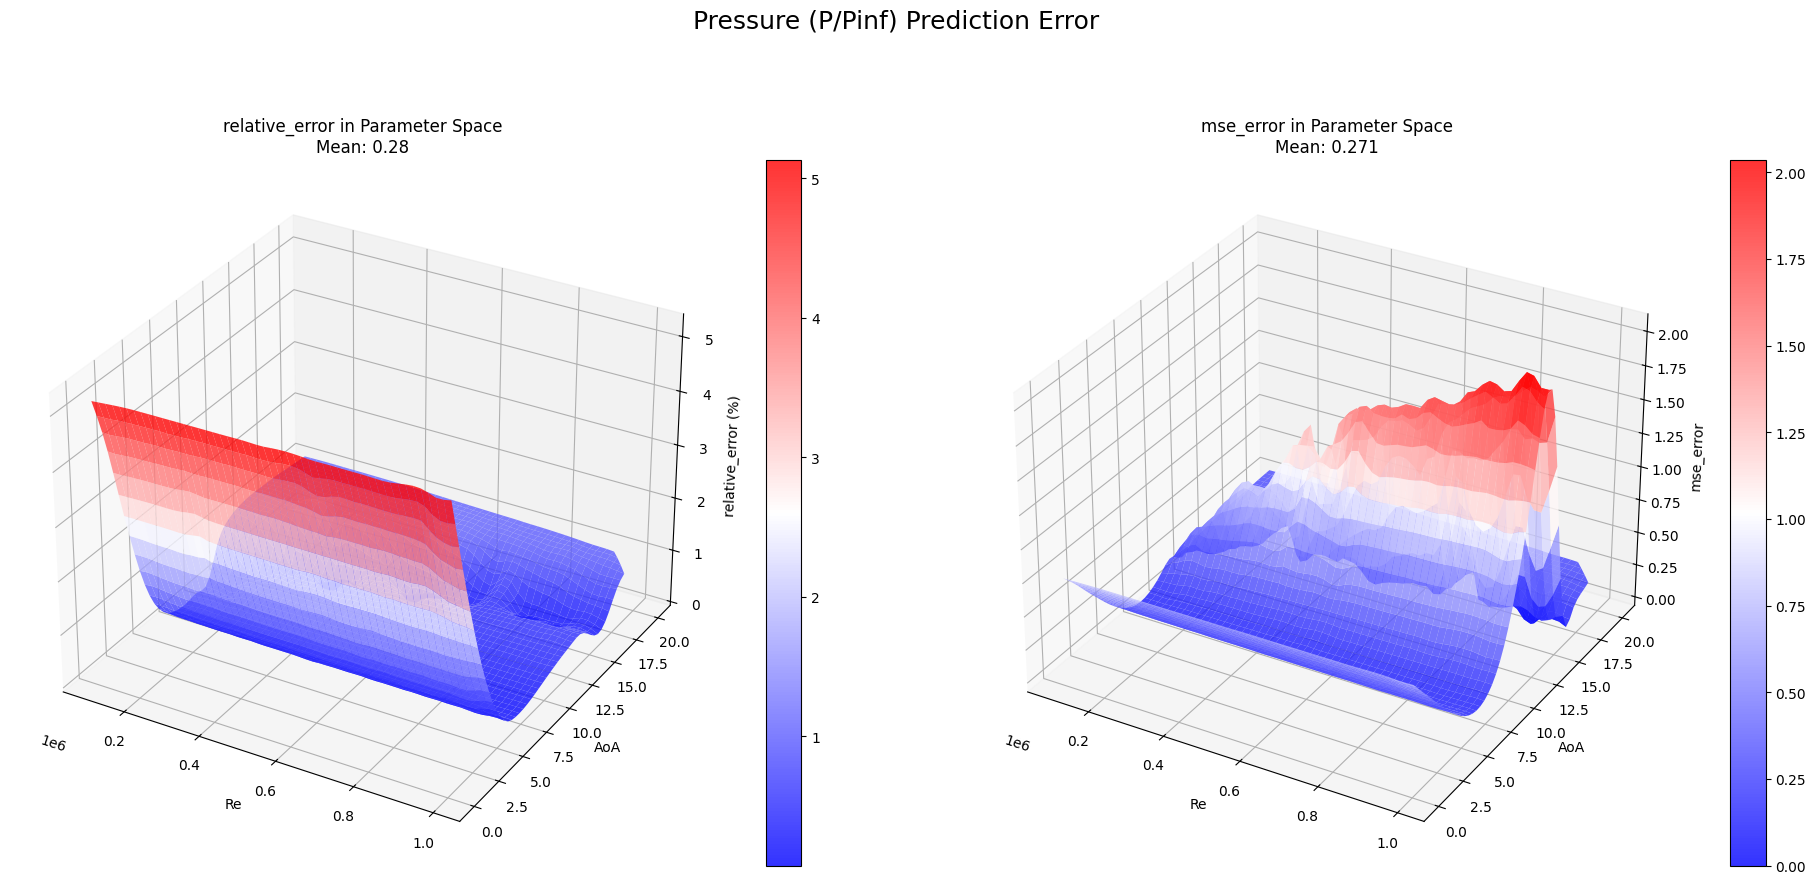

In [ ]:
# Create a single figure with two subplots side by side
fig = plt.figure(figsize=(20, 8))

ax1 = fig.add_subplot(121, projection='3d')
# Create a surface plot instead of scatter
from scipy.interpolate import griddata
import numpy as np

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), error_values_1, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
# surface1 = ax1.plot_trisurf(params_list[:, 0], params_list[:, 1], error_values_1, cmap='bwr', alpha=0.8)


surface1 = ax1.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax1.set_xlabel('Re')
ax1.set_ylabel('AoA')
ax1.set_zlabel(f'{plot_error[0]} (%)')
# ax1.set_zlim(0, 100)
ax1.set_title(f'{plot_error[0]} in Parameter Space\nMean: {ae_total_error[f"total_{plot_error[0]}"][0]:.2f}')
plt.colorbar(surface1, ax=ax1)

# Second subplot - {plot_error[0]}
ax2 = fig.add_subplot(122, projection='3d')
# Create a surface plot instead of scatter

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), error_values_2, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
surface2 = ax2.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax2.set_xlabel('Re')
ax2.set_ylabel('AoA')
ax2.set_zlabel(f'{plot_error[1]}')
# ax2.set_zlim(0, 1)
ax2.set_title(f'{plot_error[1]} in Parameter Space\nMean: {ae_total_error[f"total_{plot_error[1]}"][0]:.3f}')
plt.suptitle(f'{variable_title_list[variable_index]} Prediction Error', y = 1.1, fontsize = 18)
plt.colorbar(surface2, ax=ax2)

plt.tight_layout()
plt.show()

## Full test mode error

In [ ]:
variable_index = 0
params_list = np.array(params_list).reshape(-1, 2)
pred_rel_error_values = np.array(full_pred_error_list[plot_error[0]][variable_index])
mapping_rel_error_values = np.array(full_mapping_error_list[plot_error[0]][variable_index])
pred_mse_error_values = np.array(full_pred_error_list[plot_error[1]][variable_index])
mapping_mse_error_values = np.array(full_mapping_error_list[plot_error[1]][variable_index])

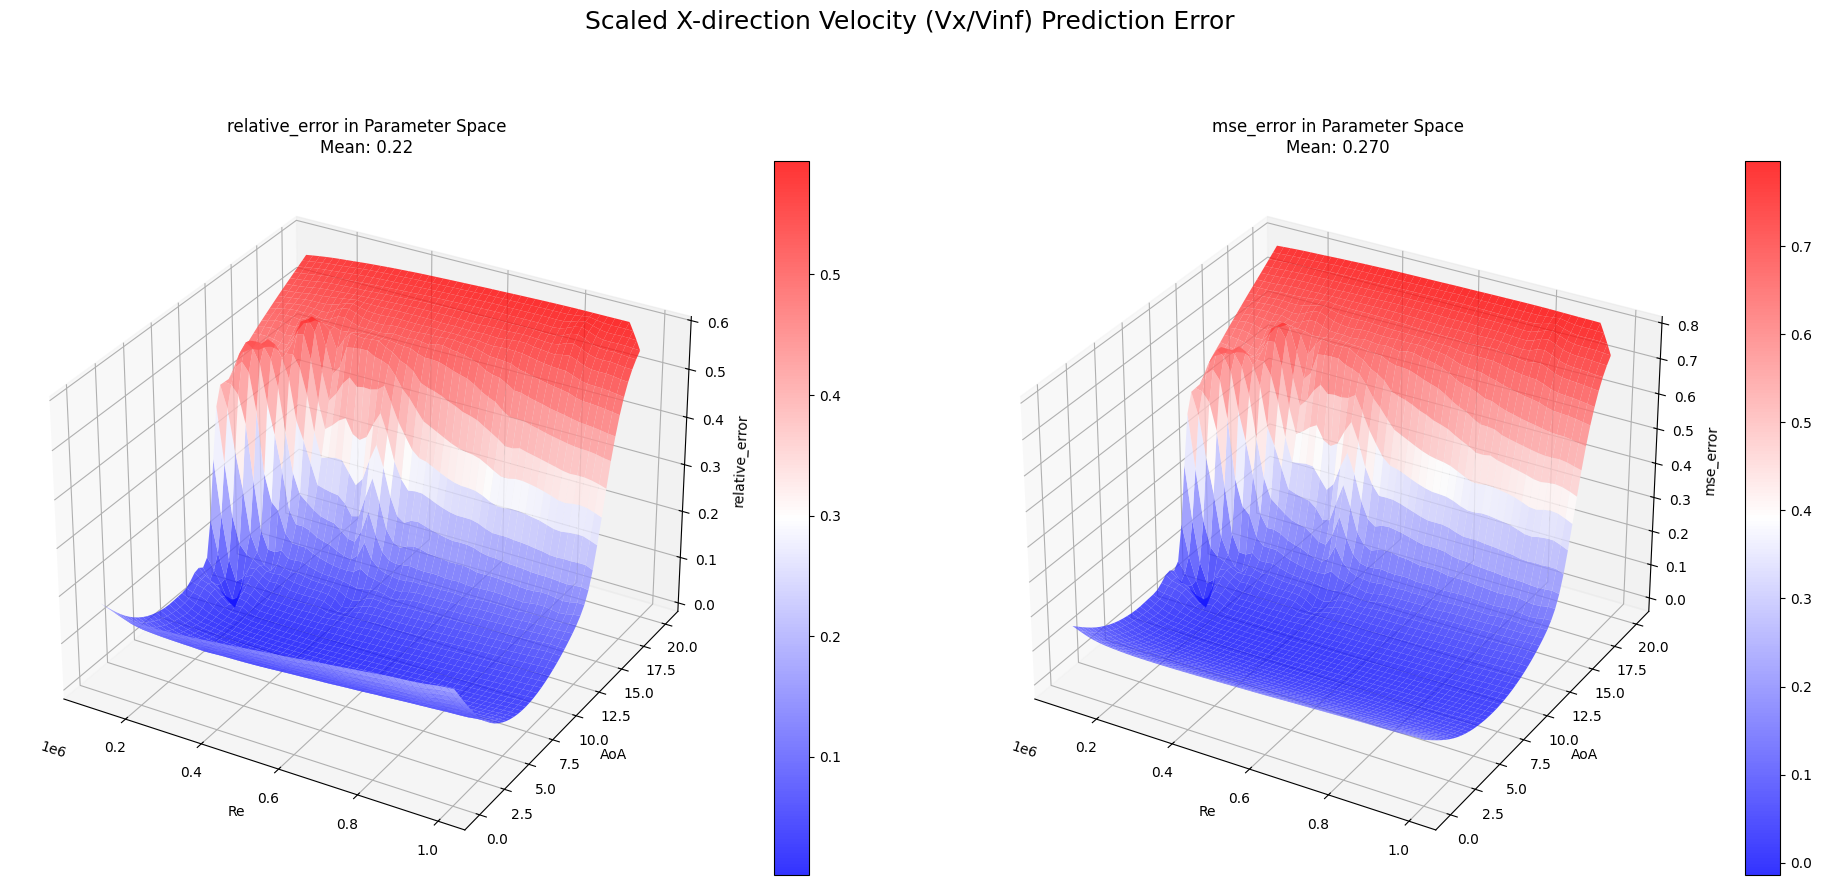

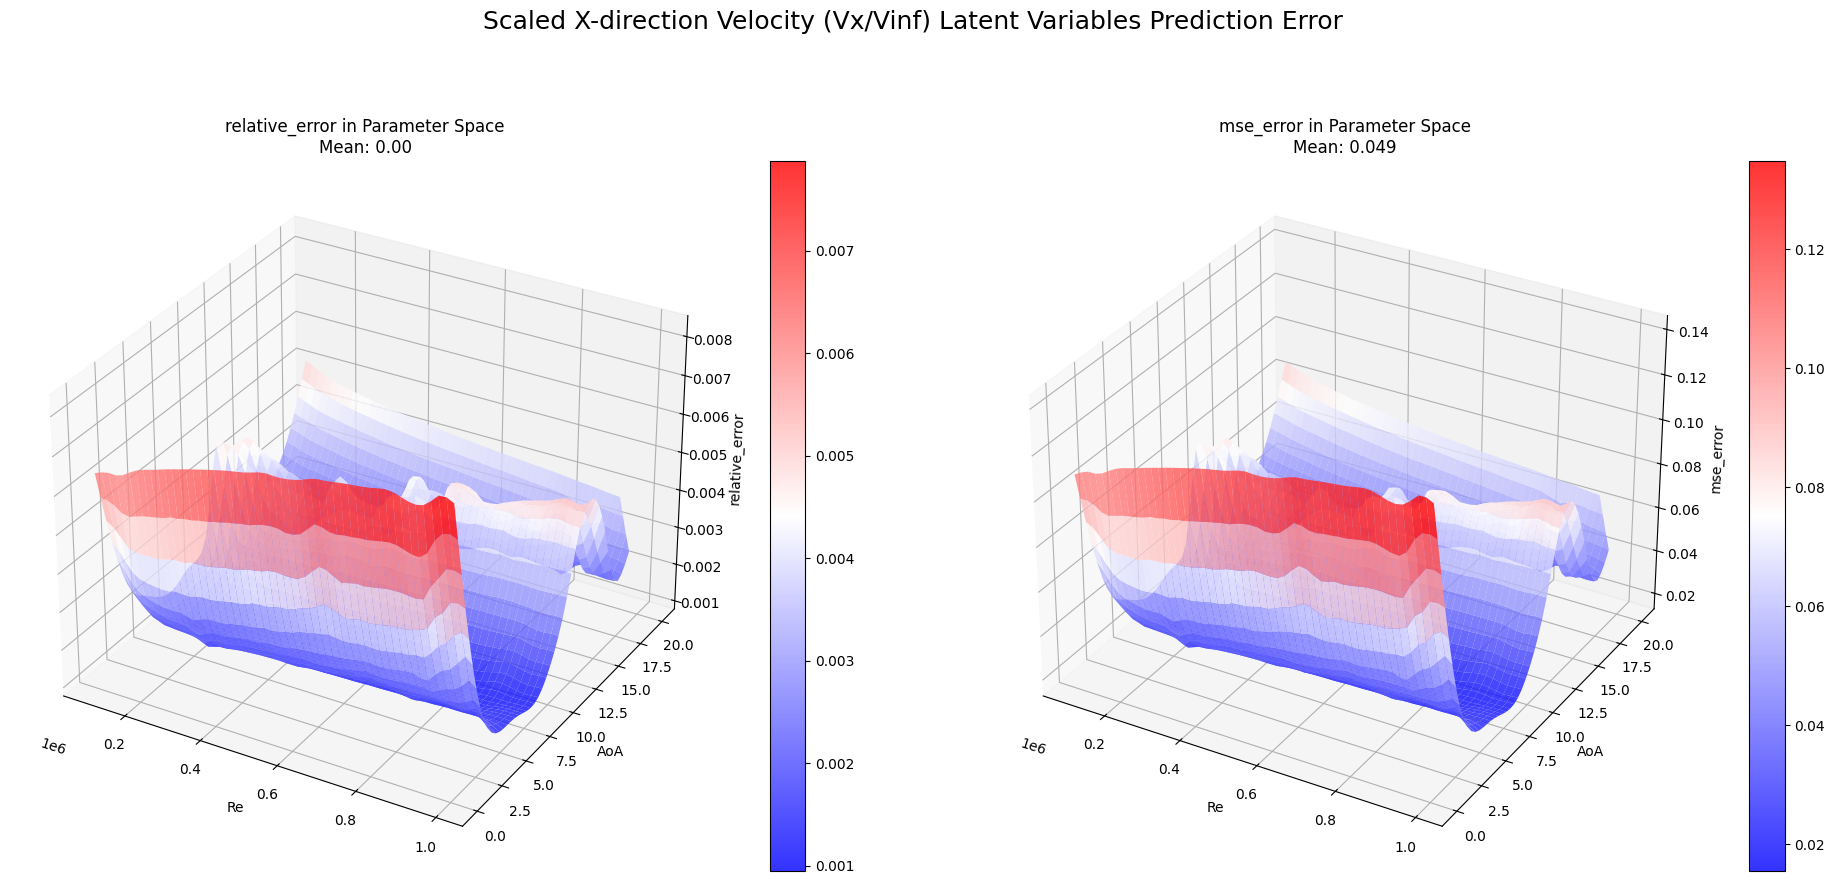

In [ ]:
# Create a single figure with two subplots side by side
fig = plt.figure(figsize=(20, 8))

ax1 = fig.add_subplot(121, projection='3d')
# Create a surface plot instead of scatter
from scipy.interpolate import griddata
import numpy as np

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), pred_rel_error_values, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
# surface1 = ax1.plot_trisurf(params_list[:, 0], params_list[:, 1], pred_rel_error_values, cmap='bwr', alpha=0.8)


surface1 = ax1.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax1.set_xlabel('Re')
ax1.set_ylabel('AoA')
ax1.set_zlabel(f'{plot_error[0]}')
# ax1.set_zlim(0, 100)
ax1.set_title(f'{plot_error[0]} in Parameter Space\nMean: {full_pred_total_error[f"total_{plot_error[0]}"][0]:.2f}')
plt.colorbar(surface1, ax=ax1)

# Second subplot - {plot_error[0]}
ax2 = fig.add_subplot(122, projection='3d')
# Create a surface plot instead of scatter

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), pred_mse_error_values, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
surface2 = ax2.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax2.set_xlabel('Re')
ax2.set_ylabel('AoA')
ax2.set_zlabel(f'{plot_error[1]}')
# ax2.set_zlim(0, 1)
ax2.set_title(f'{plot_error[1]} in Parameter Space\nMean: {full_pred_total_error[f"total_{plot_error[1]}"][0]:.3f}')
plt.suptitle(f'{variable_title_list[variable_index]} Prediction Error', y = 1.1, fontsize = 18)
plt.colorbar(surface2, ax=ax2)

plt.tight_layout()
plt.show()

# Create a single figure with two subplots side by side
fig = plt.figure(figsize=(20, 8))


ax1 = fig.add_subplot(121, projection='3d')
# Create a surface plot instead of scatter
from scipy.interpolate import griddata
import numpy as np

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), mapping_rel_error_values, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
surface1 = ax1.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax1.set_xlabel('Re')
ax1.set_ylabel('AoA')
ax1.set_zlabel(f'{plot_error[0]}')
# ax1.set_zlim(0, 100)
ax1.set_title(f'{plot_error[0]} in Parameter Space\nMean: {full_mapping_total_error[f"total_{plot_error[0]}"][0]:.2f}')
plt.colorbar(surface1, ax=ax1)

# Second subplot - {plot_error[0]}
ax2 = fig.add_subplot(122, projection='3d')
# Create a surface plot instead of scatter

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), mapping_mse_error_values, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
surface2 = ax2.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax2.set_xlabel('Re')
ax2.set_ylabel('AoA')
ax2.set_zlabel(f'{plot_error[1]}')
# ax2.set_zlim(0, 1)
ax2.set_title(f'{plot_error[1]} in Parameter Space\nMean: {full_mapping_total_error[f"total_{plot_error[1]}"][0]:.3f}')
plt.suptitle(f'{variable_title_list[variable_index]} Latent Variables Prediction Error', y = 1.1, fontsize = 18)
plt.colorbar(surface2, ax=ax2)

plt.tight_layout()
plt.show()

In [ ]:
from src.training.fine_tune_mapping import fine_tune_mapping

fine_tune_mapping(model = model, 
                  device = device, 
                  train_loader = train_loader, 
                  val_loader = val_loader, 
                  epoch = 100)

100%|██████████| 100/100 [17:50<00:00, 10.70s/it, train_loss=0.000066, val_loss=0.000180]


({'train_loss': [24.77475850135088,
   0.11190181124423232,
   0.0405545406841806,
   0.01888674840863262,
   0.0105395883188716,
   0.00706983206993235,
   0.0068459484975651975,
   0.005366141912859997,
   0.0038120771824781386,
   0.0028300641403932658,
   0.002838516076527802,
   0.003443046085469957,
   0.004209387423803231,
   0.004754652282489198,
   0.005820301557624978,
   0.00615830890102578,
   0.006259516021236778,
   0.005236700739312385,
   0.00483721582817712,
   0.0057993209521685326,
   0.006596749344108892,
   0.009244386179904853,
   0.007042998624300318,
   0.004101582433629249,
   0.003678644959083093,
   0.00449095013069122,
   0.005398310168779322,
   0.005241602431384048,
   0.005003775014275951,
   0.0036541904539002905,
   0.0024034252182380963,
   0.0018635575975557523,
   0.0017464540616076972,
   0.001670263774992366,
   0.0014911346856804032,
   0.0012770919158356265,
   0.0010730571117684511,
   0.000915724371277195,
   0.0008188177540432662,
   0.0007530

In [ ]:
from src.utils.metrics import mse_error, mae_error, rmse_error, relative_error
from src.training.test import test
import pandas as pd

error_func = [mse_error, mae_error, rmse_error, relative_error]
params_list, full_test, ae_test = test(model = model, 
                                 test_loader = val_loader,
                                 device = device, 
                                 error_func = error_func)

test_results, full_pred_total_error, full_mapping_total_error, full_pred_error_list, full_mapping_error_list, full_estimated_latent_var_list = full_test
ae_test_results, ae_total_error, ae_error_list, ae_latent_var_list  = ae_test

print(f"Total Test Mode Mapping Error: \n{pd.DataFrame(full_mapping_total_error)}")
print(f"Total Test Mode Error: \n{pd.DataFrame(full_pred_total_error)}")
print(f"Total AE Mode Error: \n{pd.DataFrame(ae_total_error)}")

Total Test Mode Mapping Error: 
   total_mse_error  total_mae_error  total_rmse_error  total_relative_error
0          0.00018         0.008525           0.01068              0.000018
1          0.00018         0.008525           0.01068              0.000018
2          0.00018         0.008525           0.01068              0.000018
Total Test Mode Error: 
   total_mse_error  total_mae_error  total_rmse_error  total_relative_error
0         0.273130         0.287123          0.520199              0.277918
1         0.402193         0.440826          0.598003              0.556469
2         0.454724         0.315688          0.626936              1.233713
Total AE Mode Error: 
   total_mse_error  total_mae_error  total_rmse_error  total_relative_error
0         0.270776         0.285963          0.517986              0.275668
1         0.399116         0.438403          0.595502              0.551741
2         0.453353         0.314898          0.625421              1.224666


In [ ]:
variable_index = 0
params_list = np.array(params_list).reshape(-1, 2)
pred_rel_error_values = np.array(full_pred_error_list[plot_error[0]][variable_index])
mapping_rel_error_values = np.array(full_mapping_error_list[plot_error[0]][variable_index])
pred_mse_error_values = np.array(full_pred_error_list[plot_error[1]][variable_index])
mapping_mse_error_values = np.array(full_mapping_error_list[plot_error[1]][variable_index])

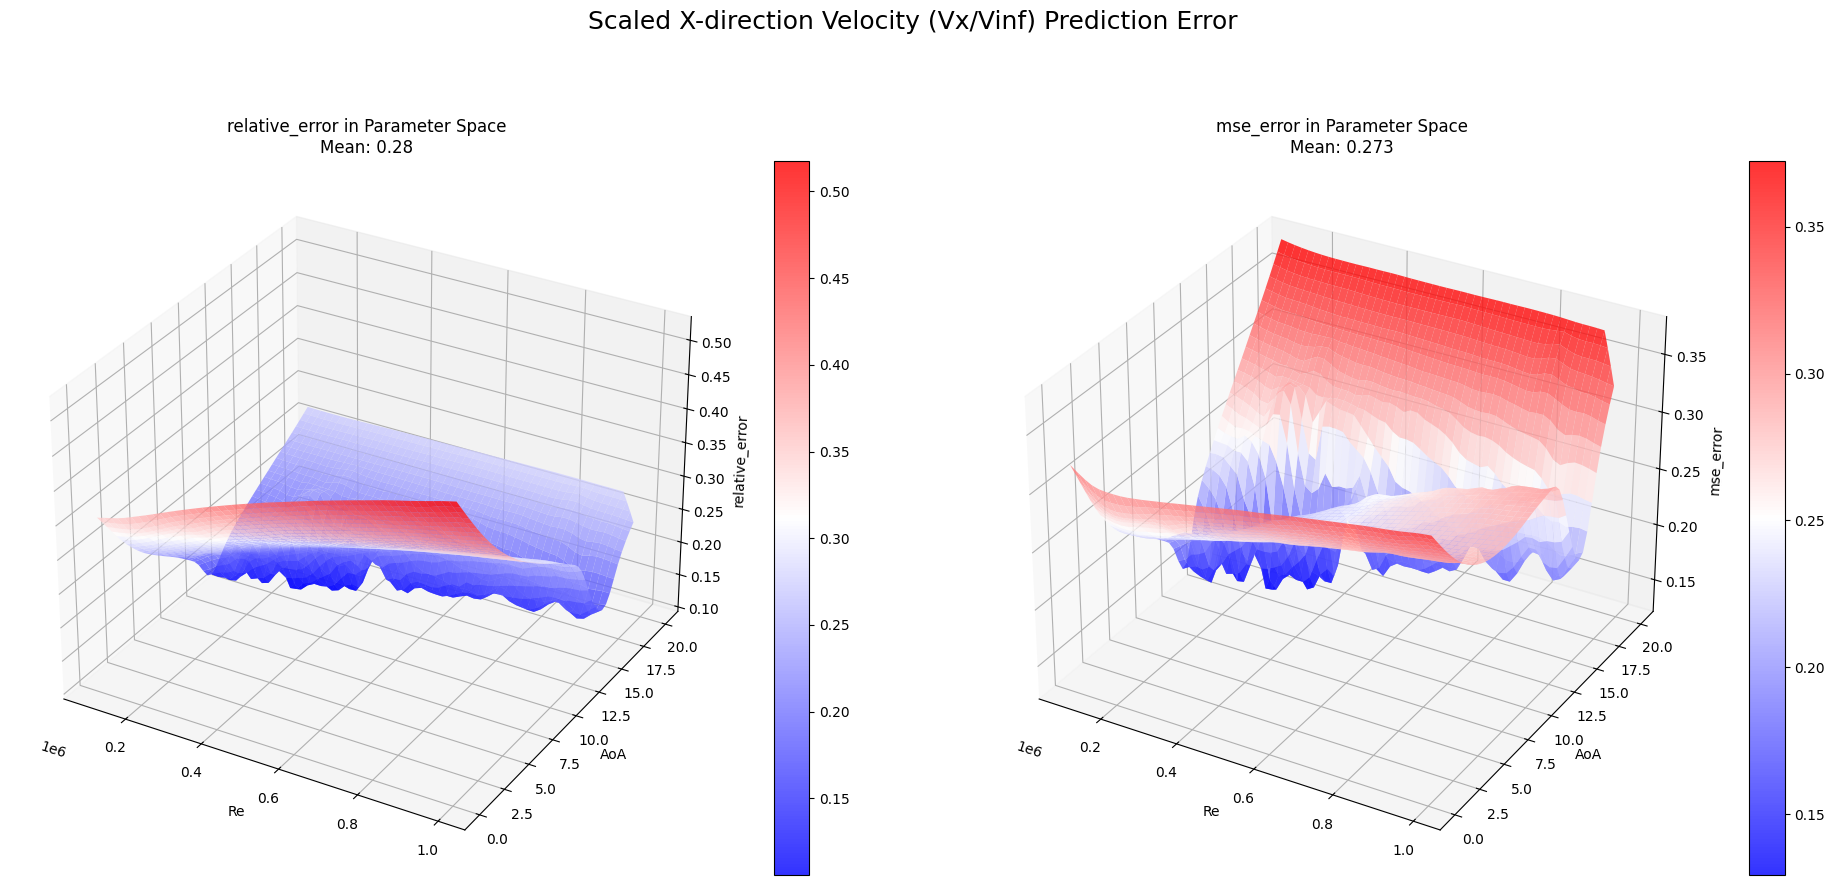

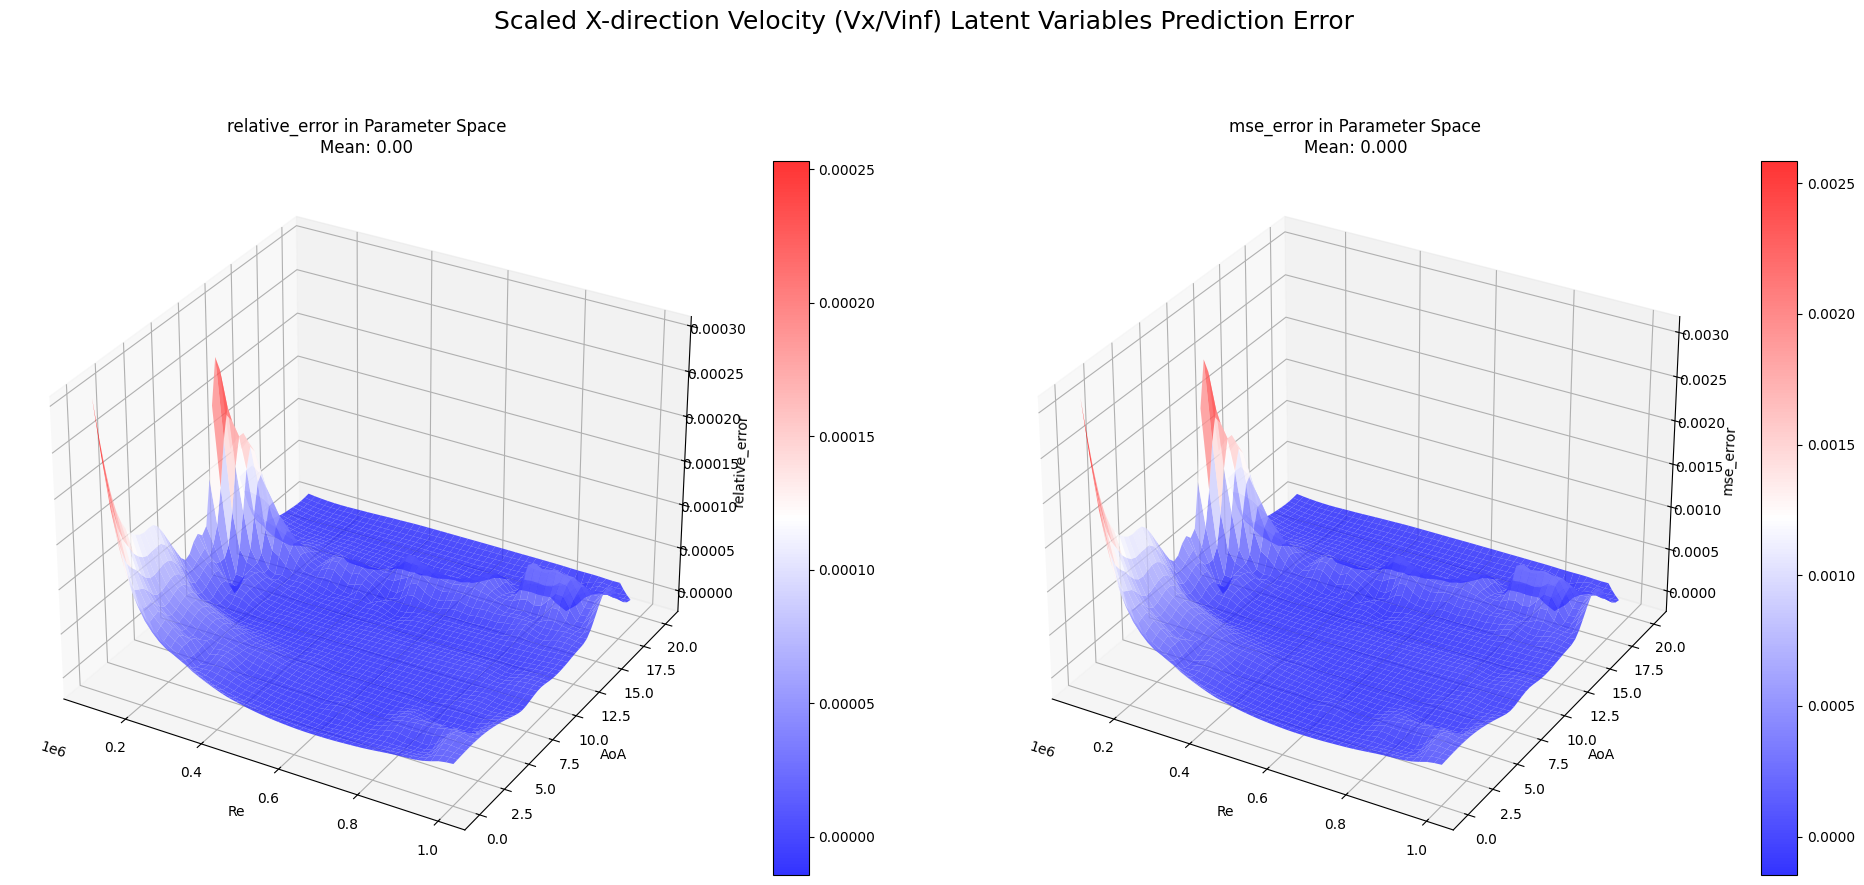

In [ ]:
# Create a single figure with two subplots side by side
fig = plt.figure(figsize=(20, 8))

ax1 = fig.add_subplot(121, projection='3d')
# Create a surface plot instead of scatter
from scipy.interpolate import griddata
import numpy as np

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), pred_rel_error_values, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
# surface1 = ax1.plot_trisurf(params_list[:, 0], params_list[:, 1], pred_rel_error_values, cmap='bwr', alpha=0.8)


surface1 = ax1.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax1.set_xlabel('Re')
ax1.set_ylabel('AoA')
ax1.set_zlabel(f'{plot_error[0]}')
# ax1.set_zlim(0, 100)
ax1.set_title(f'{plot_error[0]} in Parameter Space\nMean: {full_pred_total_error[f"total_{plot_error[0]}"][0]:.2f}')
plt.colorbar(surface1, ax=ax1)

# Second subplot - {plot_error[0]}
ax2 = fig.add_subplot(122, projection='3d')
# Create a surface plot instead of scatter

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), pred_mse_error_values, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
surface2 = ax2.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax2.set_xlabel('Re')
ax2.set_ylabel('AoA')
ax2.set_zlabel(f'{plot_error[1]}')
# ax2.set_zlim(0, 1)
ax2.set_title(f'{plot_error[1]} in Parameter Space\nMean: {full_pred_total_error[f"total_{plot_error[1]}"][0]:.3f}')
plt.suptitle(f'{variable_title_list[variable_index]} Prediction Error', y = 1.1, fontsize = 18)
plt.colorbar(surface2, ax=ax2)

plt.tight_layout()
plt.show()

# Create a single figure with two subplots side by side
fig = plt.figure(figsize=(20, 8))


ax1 = fig.add_subplot(121, projection='3d')
# Create a surface plot instead of scatter
from scipy.interpolate import griddata
import numpy as np

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), mapping_rel_error_values, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
surface1 = ax1.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax1.set_xlabel('Re')
ax1.set_ylabel('AoA')
ax1.set_zlabel(f'{plot_error[0]}')
# ax1.set_zlim(0, 100)
ax1.set_title(f'{plot_error[0]} in Parameter Space\nMean: {full_mapping_total_error[f"total_{plot_error[0]}"][0]:.2f}')
plt.colorbar(surface1, ax=ax1)

# Second subplot - {plot_error[0]}
ax2 = fig.add_subplot(122, projection='3d')
# Create a surface plot instead of scatter

# Create a regular grid for interpolation
xi = np.linspace(params_list[:, 0].min(), params_list[:, 0].max(), 50)
yi = np.linspace(params_list[:, 1].min(), params_list[:, 1].max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolate the error values onto the regular grid
zi_grid = griddata((params_list[:, 0], params_list[:, 1]), mapping_mse_error_values, (xi_grid, yi_grid), method='cubic')

# Create the surface plot
surface2 = ax2.plot_surface(xi_grid, yi_grid, zi_grid, cmap='bwr', alpha=0.8)
ax2.set_xlabel('Re')
ax2.set_ylabel('AoA')
ax2.set_zlabel(f'{plot_error[1]}')
# ax2.set_zlim(0, 1)
ax2.set_title(f'{plot_error[1]} in Parameter Space\nMean: {full_mapping_total_error[f"total_{plot_error[1]}"][0]:.3f}')
plt.suptitle(f'{variable_title_list[variable_index]} Latent Variables Prediction Error', y = 1.1, fontsize = 18)
plt.colorbar(surface2, ax=ax2)

plt.tight_layout()
plt.show()

MSE error: 0.3730837404727936
Using v_range: 10.344905853271484
Using v_range: 10.344905853271484


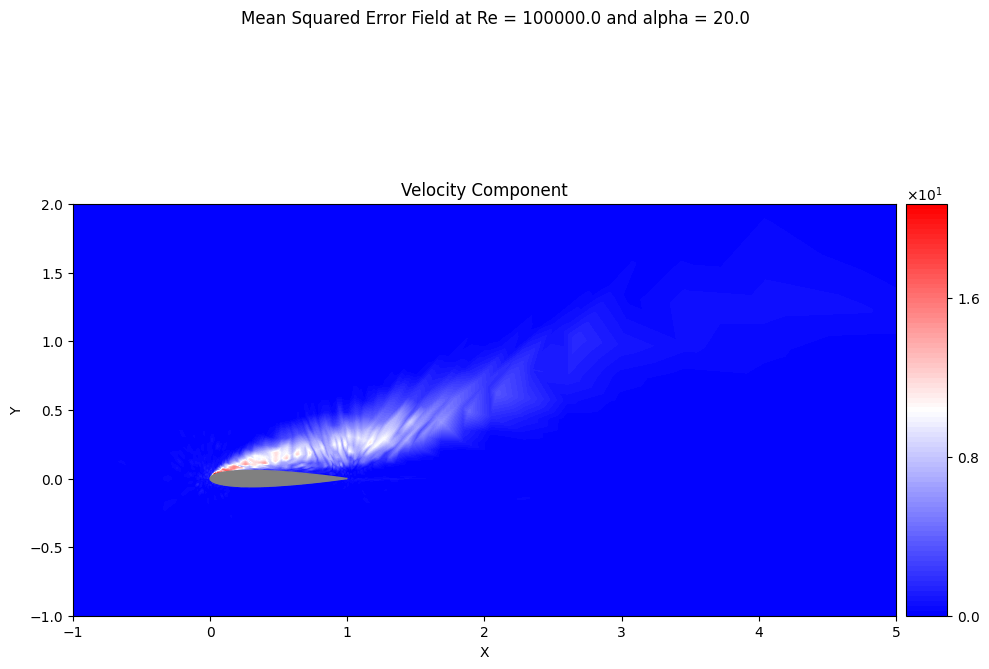

MSE error: 0.5122369527816772
Using v_range: 15.991209983825684
Using v_range: 15.991209983825684


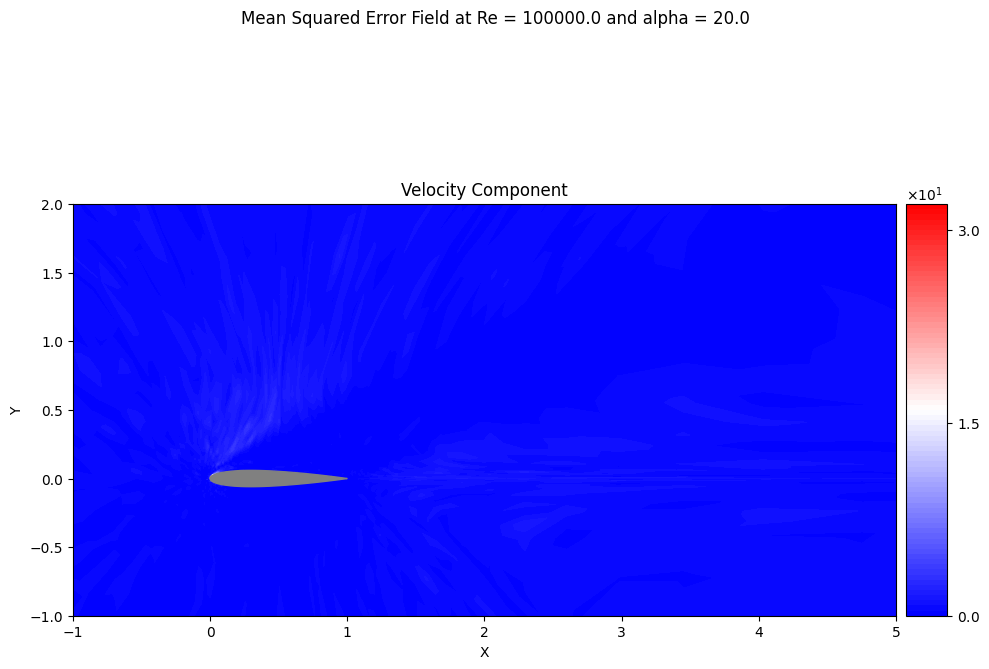

MSE error: 0.2910004258155823
Using v_range: 14.115371704101562
Using v_range: 14.115371704101562


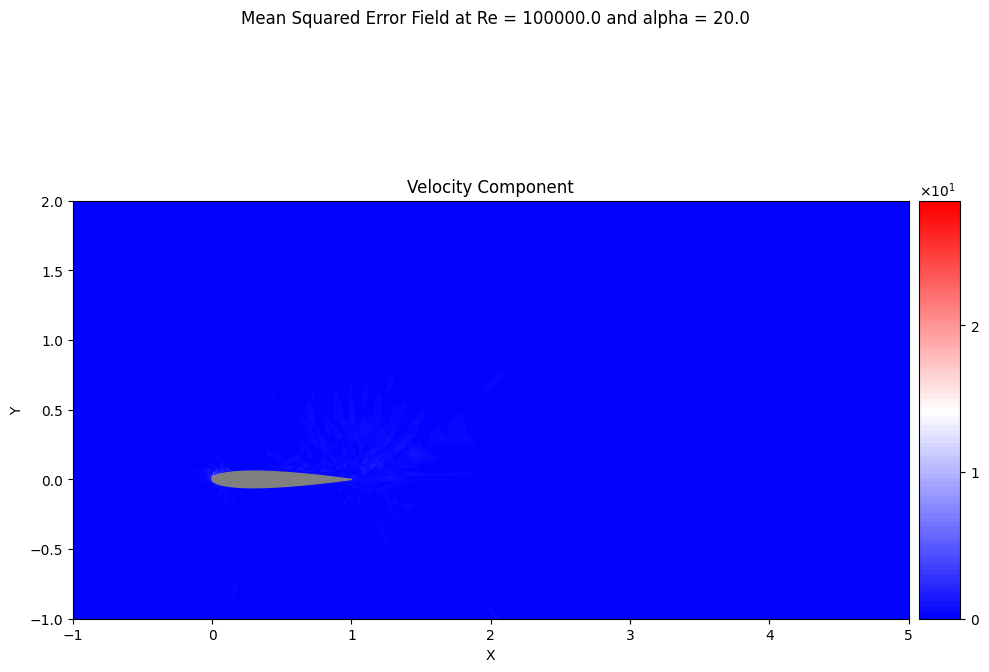

In [ ]:
# v_range=[-0.17144335806369781, 0.17144335806369781]
# v_range = [0, 1e-2]
v_range = None
colormap='bwr'

# print(f"Ux MSE: {torch.nn.functional.msel(input=torch.tensor(estimated_x[:, 0]), target=torch.tensor(test_plot_data.y[:, 0].cpu().numpy()), reduction='mean')}")
plot.plot_velocity_field_error(data=test_plot_data,
                               dim_index = 0, 
                               params=test_param, device = device, 
                               title=f"Mean Squared Error Field at Re = {test_param[0]} and alpha = {test_param[1]}", 
                               save=False, 
                               v_range=v_range,
                               xlim=[-1, 5], ylim=[-1, 2], 
                               colormap=colormap)

plot.plot_velocity_field_error(data=test_plot_data, 
                               dim_index = 1,
                               params=test_param, device = device, 
                               title=f"Mean Squared Error Field at Re = {test_param[0]} and alpha = {test_param[1]}", 
                               save=False, 
                               v_range=v_range,
                               xlim=[-1, 5], ylim=[-1, 2],  
                               colormap=colormap)

plot.plot_velocity_field_error(data=test_plot_data, 
                               dim_index = 2,
                               params=test_param, device = device, 
                               title=f"Mean Squared Error Field at Re = {test_param[0]} and alpha = {test_param[1]}", 
                               save=False, 
                               v_range=v_range,
                               xlim=[-1, 5], ylim=[-1, 2],  
                               colormap=colormap)

### Pyvista Plotting

In [ ]:
from src.utils.plot import PyvistaPlot
from src.utils.commons import load_model
import gc
import numpy as np
import torch
from itertools import product
from warnings import filterwarnings

from src.utils.commons import get_config, get_device, set_seed
from src.data.loader import GraphDataset
from src.utils.commons import get_config

filterwarnings('ignore')
torch.cuda.empty_cache()
gc.collect()

config = get_config('configs/VEL_P_NACA0012Cheb.yaml')
set_seed(config['config']['seed'])
num_epochs = config['training']['epochs']

test_dataset = GraphDataset(config = config['config'], split = 'val')
device = get_device()

mu1 = np.array([10e4, 15e4, 20e4, 25e4, 30e4, 35e4, 40e4, 45e4, 50e4, 55e4, 60e4, 65e4, 70e4, 75e4, 80e4, 85e4, 90e4, 95e4, 100e4])
mu2 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
mu_space = [mu1, mu2]
params = torch.tensor(np.array(list(product(*mu_space))))
params = params.to(device)
model_name = config['training']['model_name']
num_epochs = config['training']['epochs']

model = load_model(f"artifacts/surface/{model_name}/{model_name}_best_model_{num_epochs}.pth", config=config, num_graphs=test_dataset.num_graphs)
model = model.to(device)
plot = PyvistaPlot(vtu_dir = "dataset/flows", model=model, dataset=test_dataset)

TypeError: load_model() got an unexpected keyword argument 'num_graphs'

In [ ]:
import pyvista as pv
index = 1
mesh = pv.read(f"dataset/flows/configuration_{index}.vtu")
mesh.clear_data()
mesh.point_data["Pressure"] = test_dataset[test_dataset.file_index.index(index)].x.detach().cpu().numpy()
mesh
# mesh.write_vtu("dataset/flows/configuration_0.vtu")

UnstructuredGrid (0x2648bc35300)
  N Cells:    14336
  N Points:   14576
  X Bounds:   -4.845e+02, 5.010e+02
  Y Bounds:   -5.078e+02, 5.078e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   1

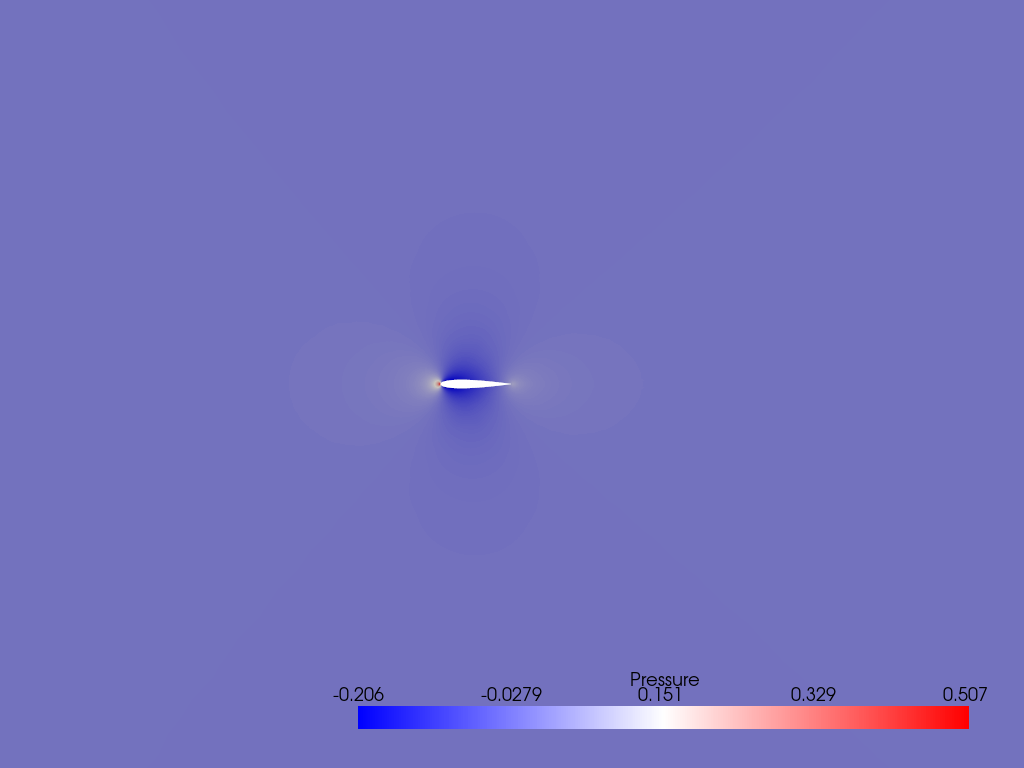

In [ ]:
plotter = pv.Plotter()
plotter.add_mesh(mesh, scalars='Pressure', cmap='bwr')
plotter.view_xy()
# plotter.zoom_camera(1)
plotter.camera_position = [
    (0, 0, 20),   # camera location
    (1, 0, 0),      # focal point (center of the mesh)
    (0, 0, 0)       # view up vector (Z axis is "up")
]
plotter.legend()
# plotter.
# plotter.set_focal_point([0, 0, 0])
plotter.show()

# Post processing

In [ ]:
import gc
import numpy as np
import matplotlib.pyplot as plt
import torch
from itertools import product
from warnings import filterwarnings

from src.utils.commons import get_config, get_device, set_seed
from torch_geometric.loader import DataLoader
from src.data.loader import GraphDataset
from src.utils.commons import get_config, load_model

filterwarnings('ignore')
torch.cuda.empty_cache()
gc.collect()

config = get_config('configs/VEL_P_NACA0012Cheb.yaml')
set_seed(config['config']['seed'])
device = get_device()
model_name = config['training']['model_name']
num_epochs = config['training']['epochs']

test_dataset = GraphDataset(config = config['config'], split = 'val')
test_loader = DataLoader(dataset=test_dataset, 
                        batch_size=1, 
                        shuffle=False,
                        num_workers=config['training']['num_workers'])
mu1 = np.array([10e4, 15e4, 20e4, 25e4, 30e4, 35e4, 40e4, 45e4, 50e4, 55e4, 60e4, 65e4, 70e4, 75e4, 80e4, 85e4, 90e4, 95e4, 100e4])
mu2 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
mu_space = [mu1, mu2]
params = torch.tensor(np.array(list(product(*mu_space))))
params = params.to(device)
surface_mask = test_dataset.surface_mask
num_graphs = test_dataset.num_graphs

model = load_model(f"artifacts/surface/{model_name}/{model_name}_best_model_{num_epochs}.pth", config=config, num_graphs=test_dataset.num_graphs)
model = model.to(device)

In [ ]:
from src.utils.metrics import mse_error, mae_error, rmse_error, relative_error
from src.training.test import test

error_func = [mse_error, mae_error, rmse_error, relative_error]
test_params = params[test_dataset.file_index]
test_results, total_error = test(model, test_params, test_loader, device, error_func)

In [ ]:
total_error

{'total_mse_error': 0.03420029986465787,
 'total_mae_error': 0.06892202448467781,
 'total_rmse_error': 0.16997587942966708,
 'total_relative_error': 4.322089583647472}

# Cp

Good: 5, 6
Hmm: 3, 4, 8
Bad: 1, 2, 9, 10, 11

In [ ]:
from src.training.test import single_test

rho_inf = 2.13163
R = 287.058
T_inf = 300
viscosity_inf = 1.853e-05


model = model.to(device)
test_data = val_dataset[index]
test_data = test_data.to(device)

test_param = test_data.params
file_key = val_dataset.file_keys[index]
Re = test_data.params[0].item()
v_inf = Re * viscosity_inf
p_inf = rho_inf * R * T_inf
q_inf = 0.5 * rho_inf * v_inf**2

MSE: 5.966353455733042e-08
Relative Error: 2.4929072424129117e-06


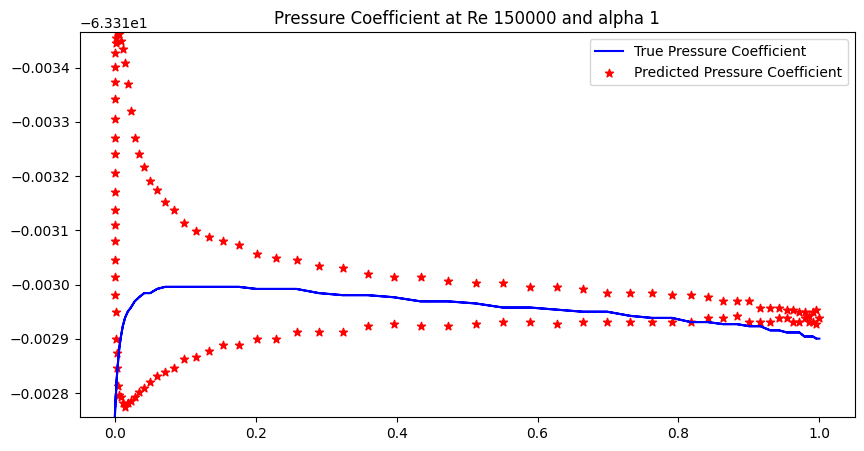

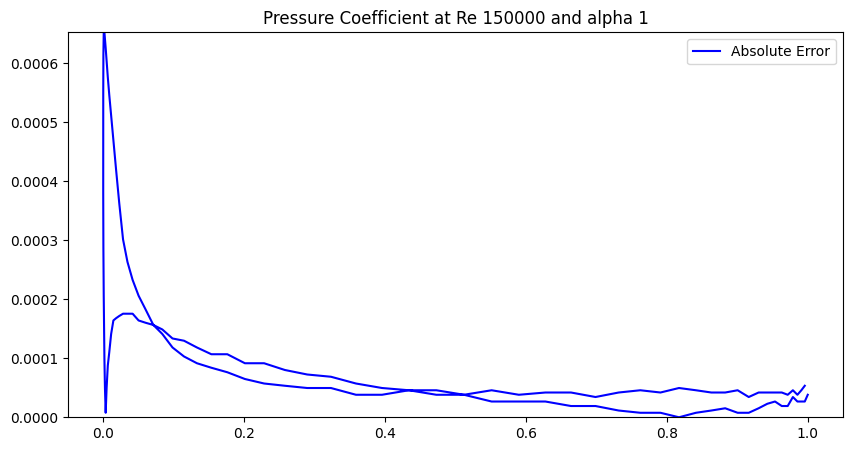

In [ ]:
from src.training.test import single_test

index = 5

rho_inf = 2.13163
R = 287.058
T_inf = 300
viscosity_inf = 1.853e-05
v_inf = 52.1572 # THIS HAS TO BE CHANGED FOR EACH RE

p_inf = rho_inf * R * T_inf
q_inf = 0.5 * rho_inf * v_inf**2

model = model.to(device)
test_data = test_dataset[index]
test_data = test_data.to(device)
test_param = params[test_dataset.file_index[index]]
file_key = test_dataset.file_keys[0].split('_')[0] + '_' + str(test_dataset.file_index[index])
surface_mask = test_dataset.surface_mask
surface_point = test_data.pos[surface_mask].detach().cpu().numpy()
upper_surface_point = surface_point[surface_point[:, 1] >= 0]
lower_surface_point = surface_point[surface_point[:, 1] < 0]

# VTU FILE
# import pyvista as pv
# import meshio
# vtu_path = f"dataset/full/flow_Re_{int(test_param[0])}_alpha_{int(test_param[1])}.vtu"
# mesh_path = r"dataset/unsteady_naca0012.su2"
# grid = pv.read(vtu_path)
# surface_p = grid["Pressure"][surface_mask,]
# surface_cp = grid["Pressure_Coefficient"][surface_mask,]
# surface_p.shape

# truth
surface_p_graph = test_data.x[surface_mask].detach().cpu().numpy()
surface_cp_graph = test_dataset.h5_file[file_key]['Cp'][:][surface_mask]
surface_cp_graph = (surface_p_graph - p_inf) / q_inf
surface_p_graph.shape

#predicted
pred_p = single_test(model, test_param, test_data, device).detach().cpu().numpy()
surface_pred_p = pred_p[surface_mask,]
surface_pred_cp = (surface_pred_p - p_inf) / q_inf
surface_pred_p.shape

cp_mse = np.mean((surface_cp_graph - surface_pred_cp) ** 2)
print(f"MSE: {cp_mse}")
cp_relative = np.mean(np.abs(surface_pred_cp - surface_cp_graph) / np.abs(surface_cp_graph))
print(f"Relative Error: {cp_relative}")

plt.figure(figsize=(10, 5))
# plt.plot(surface_point[:, 0], surface_cp_graph, label="True Pressure Coefficient", color="blue")
plt.scatter(surface_point[:, 0], surface_pred_cp, label="Predicted Pressure Coefficient", color="red", marker="*")
plt.ylim(max([max(surface_cp_graph), max(surface_pred_cp)]), min([min(surface_cp_graph), min(surface_pred_cp)]))
plt.title(f"Pressure Coefficient at Re {int(test_param[0])} and alpha {int(test_param[1])}")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(surface_point[:, 0], np.abs(surface_cp_graph - surface_pred_cp), label="Absolute Error", color="blue")
plt.ylim(0, max([max(np.abs(surface_cp_graph - surface_pred_cp))]))
plt.title(f"Pressure Coefficient at Re {int(test_param[0])} and alpha {int(test_param[1])}")
plt.legend()
plt.show()

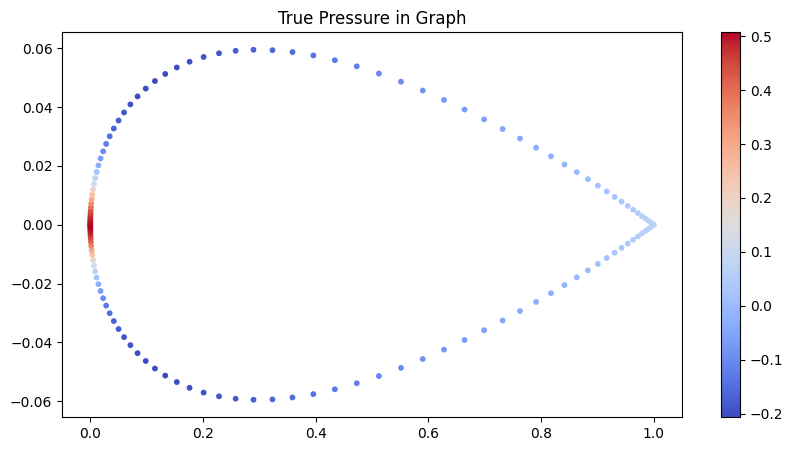

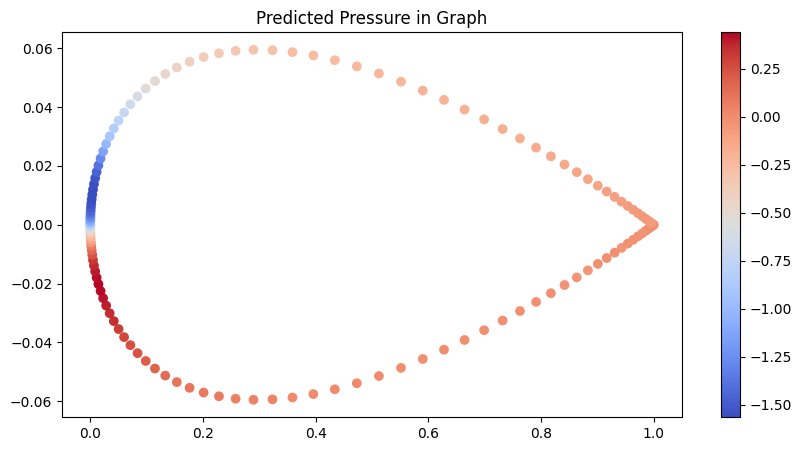

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(surface_point[:, 0], surface_point[:, 1], c=surface_p_graph, cmap="coolwarm", s=10)
plt.colorbar()
plt.title("True Pressure in Graph")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(surface_point[:, 0], surface_point[:, 1], c=surface_pred_p, cmap="coolwarm")
plt.colorbar()
plt.title("Predicted Pressure in Graph")
plt.show()

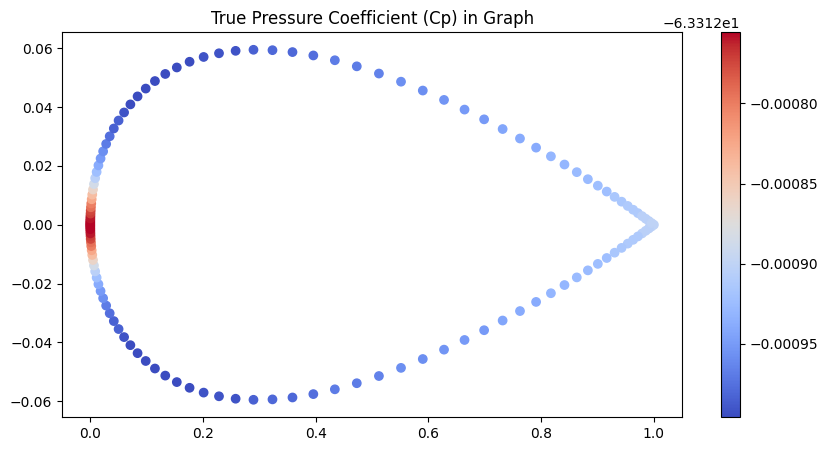

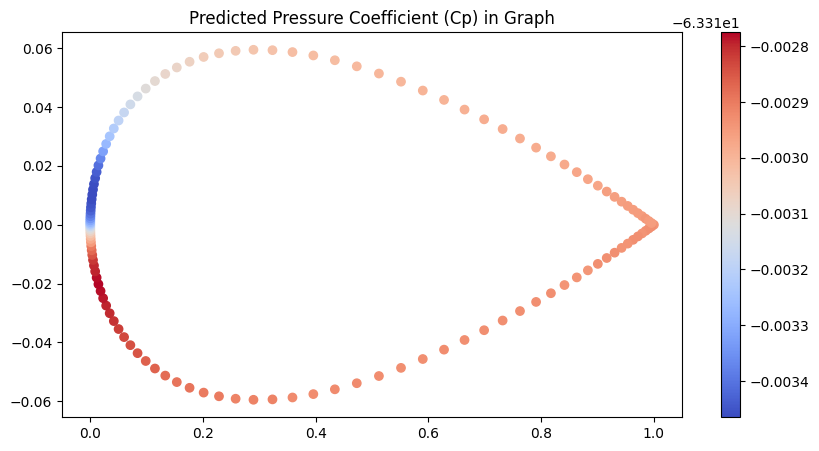

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(surface_point[:, 0], surface_point[:, 1], c=surface_cp_graph, cmap="coolwarm")
plt.colorbar()
plt.title("True Pressure Coefficient (Cp) in Graph")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(surface_point[:, 0], surface_point[:, 1], c=surface_pred_cp, cmap="coolwarm")
plt.colorbar()
plt.title("Predicted Pressure Coefficient (Cp) in Graph")
plt.show()